In [1]:
from pathlib import Path
import pandas as pd
from functools import reduce
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# Crear tablas comparativas

In [2]:
reports_dir = Path("../reports")

files = sorted(reports_dir.glob("*/*_xai_metrics_report_*.csv"))

metric_dfs = []

for metric_dir in sorted({file.parent for file in files}):
    metric_name = metric_dir.name
    metric_files = sorted(metric_dir.glob("*_xai_metrics_report_*.csv"))

    long_parts = []

    for file in metric_files:
        df = pd.read_csv(file)

        if 'observation' not in df.columns:
            continue

        df['dataset_name'] = df['dataset_name'].astype(str)
        df['model_name'] = df['model_name'].astype(str)
        df['observation'] = df['observation'].astype(str)

        id_cols = ['dataset_name', 'model_name', 'observation', 'metric_params']
        xai_cols = [c for c in df.columns if c not in id_cols]

        long_parts.append(
            df.melt(
                id_vars=['dataset_name', 'model_name', 'observation'],
                value_vars=xai_cols,
                var_name="xai_method",
                value_name=metric_name
            )
        )

    if long_parts:
        metric_df = pd.concat(long_parts, ignore_index=True)
        metric_df['xai_method'] = metric_df['xai_method'].astype(str)
        metric_dfs.append(metric_df)

if not metric_dfs:
    raise ValueError("No se han encontrado informes por observación.")

analysis_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["dataset_name", "model_name", "observation", "xai_method"],
        how="outer",
    ),
    metric_dfs,
)

Path('results').mkdir(exist_ok=True)
analysis_df.to_csv("results/metric_analysis_matrix.csv", index=False)

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


In [3]:
from pathlib import Path
import pandas as pd

reports_dir = Path("../reports")

files = sorted(reports_dir.glob("xai_metrics_report_*.csv"))

parts = []

for file in files:
    df = pd.read_csv(file)

    id_cols = ["dataset_name", "model_name", "metric", "metric_params"]
    xai_cols = [c for c in df.columns if c not in id_cols]

    long_df = df.melt(
        id_vars=["dataset_name", "model_name", "metric"],
        value_vars=xai_cols,
        var_name="xai_method",
        value_name="value"
    )

    parts.append(long_df)

agg_long = pd.concat(parts, ignore_index=True)

analysis_agg_df = agg_long.pivot_table(
    index=["dataset_name", "model_name", "xai_method"],
    columns="metric",
    values="value",
    aggfunc="mean"
).reset_index()

analysis_agg_df.columns.name = None

id_cols = ["dataset_name", "model_name", "xai_method"]

metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors="coerce")


Path('results').mkdir(exist_ok=True)
analysis_agg_df.to_csv("results/metric_analysis_agg_matrix.csv", index=False)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


# Análisis de métricas por observación

In [4]:
matrix_path = Path("results/metric_analysis_matrix.csv")
analysis_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'observation', 'xai_method']
global_metrics = ['SensitivityN']

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


## Análisis descriptivo de las métricas

In [5]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

summary = analysis_df[metric_cols].describe().T

summary['missing'] = analysis_df[metric_cols].isna().sum()
summary['missing_pct'] = analysis_df[metric_cols].isna().mean() * 100
summary['std'] = analysis_df[metric_cols].std()
summary['range'] = summary['max'] - summary['min']

summary['scope'] = 'individual'
summary.loc[summary.index.isin(global_metrics), 'scope'] = 'global'

summary['interpretation_note'] = ""
summary.loc[
    summary.index.isin(global_metrics),
    'interpretation_note'
] = "Métrica global; no se calcula por observación individual."


summary = summary[
    ['scope', 'mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'interpretation_note']
].sort_values(['scope', 'std'], ascending=False)

summary

,scope,mean,std,min,max,range,missing,missing_pct,interpretation_note
RelativeOutputStability,individual,6.393088e+08,1.958072e+10,9.010076e-01,7.436560e+11,7.436560e+11,1405,49.194678,
MaxSensitivity,individual,2.505969e+02,4.355637e+03,6.196479e-02,1.252843e+05,1.252842e+05,0,0.000000,
RelativeInputStability,individual,3.414950e+02,3.571474e+03,1.346755e-06,1.083559e+05,1.083559e+05,1407,49.264706,
AvgSensitivity,individual,1.840043e+02,3.186398e+03,3.275383e-02,9.097839e+04,9.097836e+04,140,4.901961,
LocalLipschitzEstimate,individual,5.665339e+00,3.901984e+00,1.680686e-01,3.137428e+01,3.120621e+01,0,0.000000,
NonSensitivity,individual,2.864496e+00,2.540499e+00,0.000000e+00,1.200000e+01,1.200000e+01,0,0.000000,
FaithfulnessEstimate,individual,-2.919644e-02,5.285830e-01,-9.999986e-01,9.999970e-01,1.999996e+00,0,0.000000,
Complexity,individual,1.620618e+00,5.243022e-01,-1.000089e-12,2.754321e+00,2.754321e+00,0,0.000000,
Faithfulness,individual,-1.156659e-01,5.182918e-01,-9.999955e-01,9.937259e-01,1.993721e+00,0,0.000000,
Sufficiency,individual,5.617041e-01,4.319429e-01,0.000000e+00,1.000000e+00,1.000000e+00,0,0.000000,


In [6]:
sns.set_theme(style='whitegrid', context='notebook')

summary_plot = summary.copy()

if 'scope' in summary_plot.columns:
    summary_plot = summary_plot[summary_plot['scope'] == 'individual']
else:
    summary_plot = summary_plot.drop(index=global_metrics, errors='ignore')

summary_plot = summary_plot.sort_values('std', ascending=False)

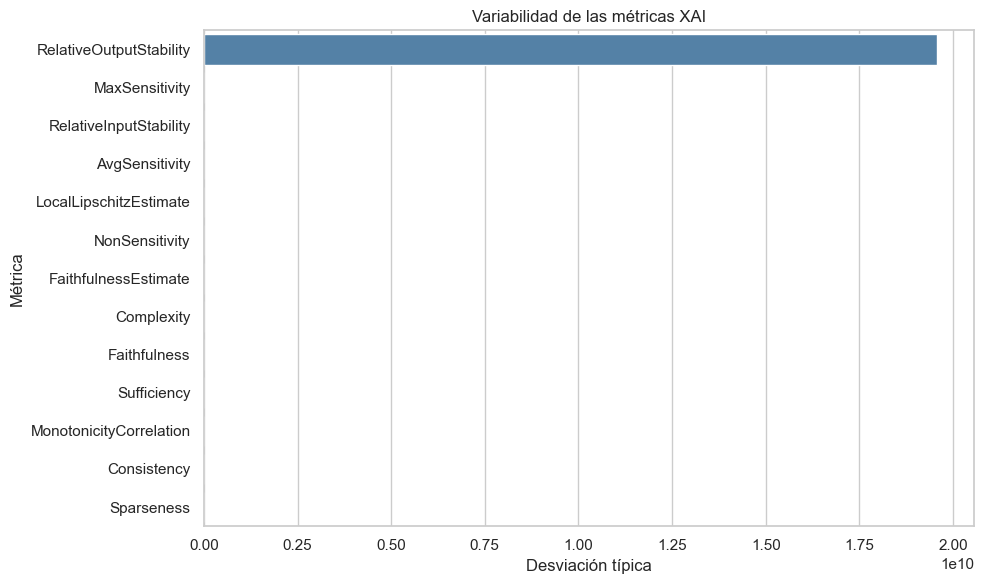

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

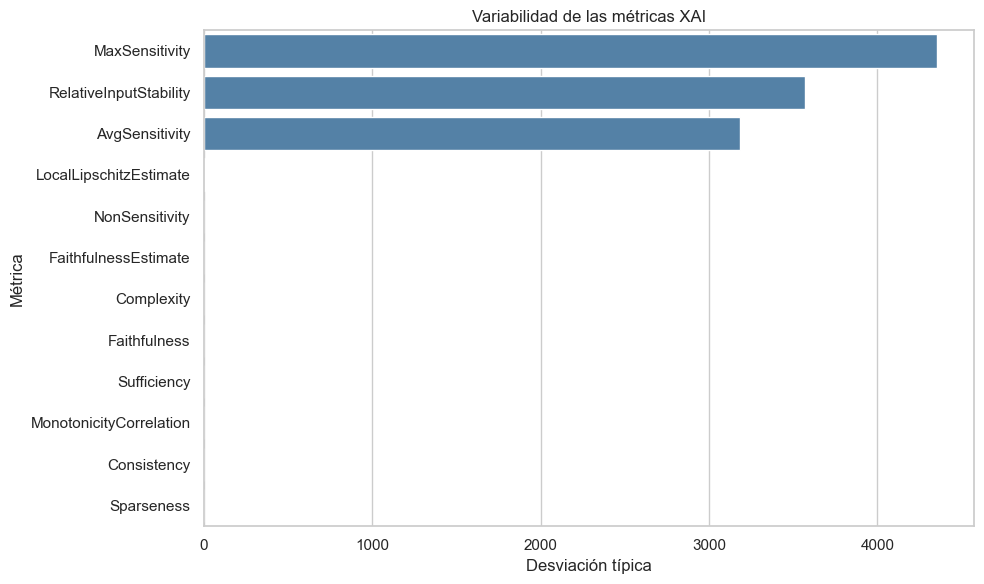

In [8]:
summary_plot_aux = summary_plot.drop(index=['RelativeOutputStability'])
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

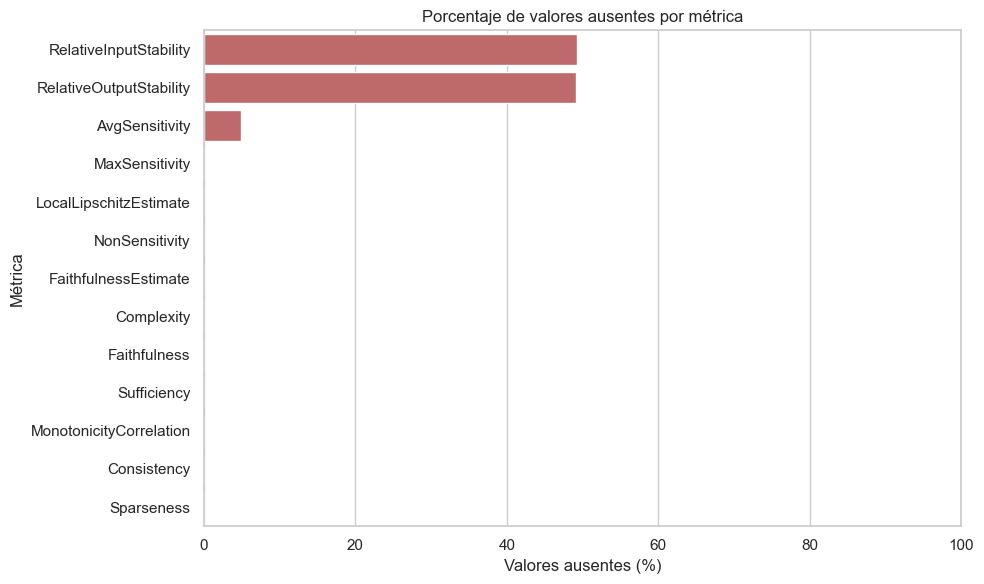

In [9]:
missing_plot = summary_plot.sort_values("missing_pct", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_plot.reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)

plt.title("Porcentaje de valores ausentes por métrica")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

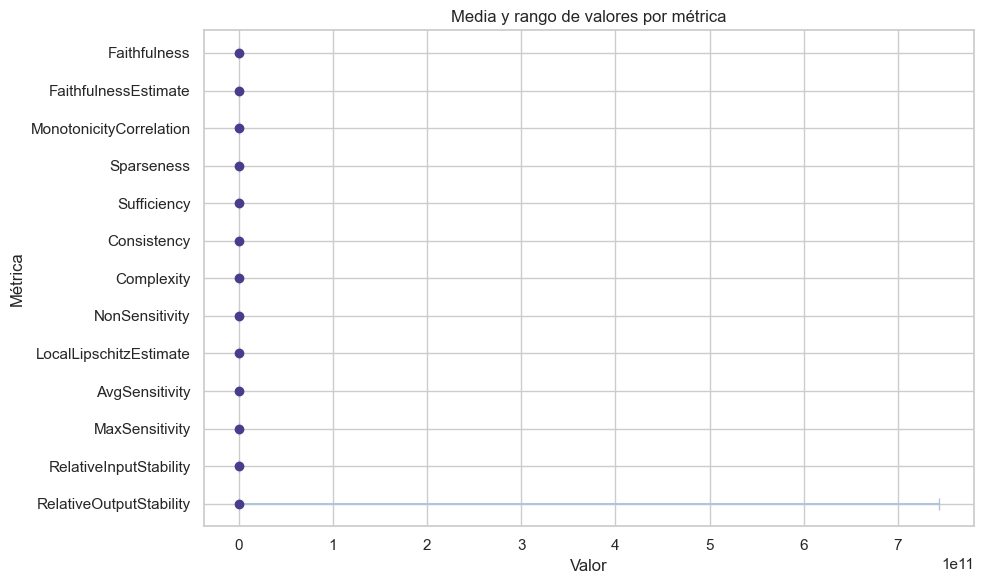

In [10]:
range_plot = summary_plot.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

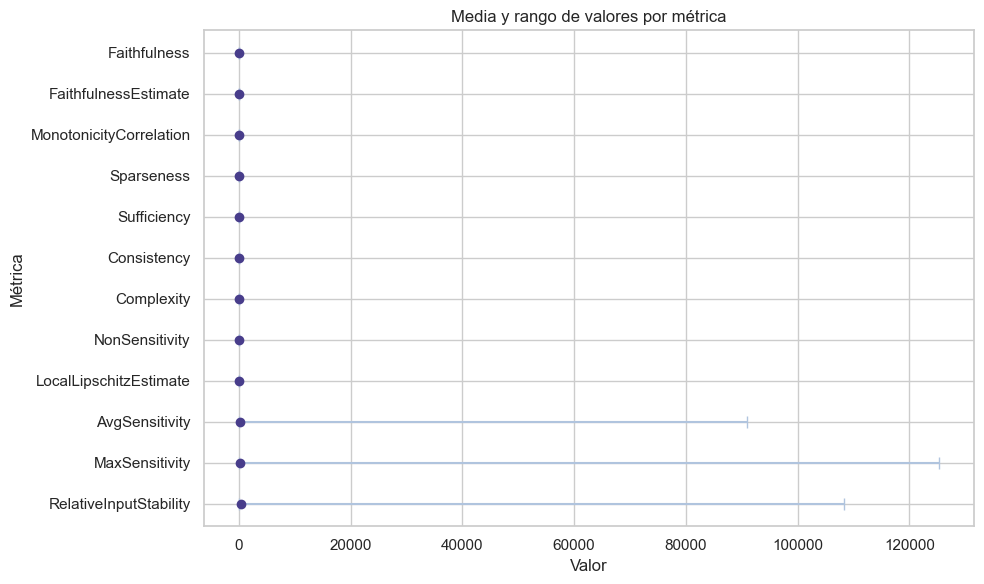

In [11]:
range_plot = summary_plot_aux.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

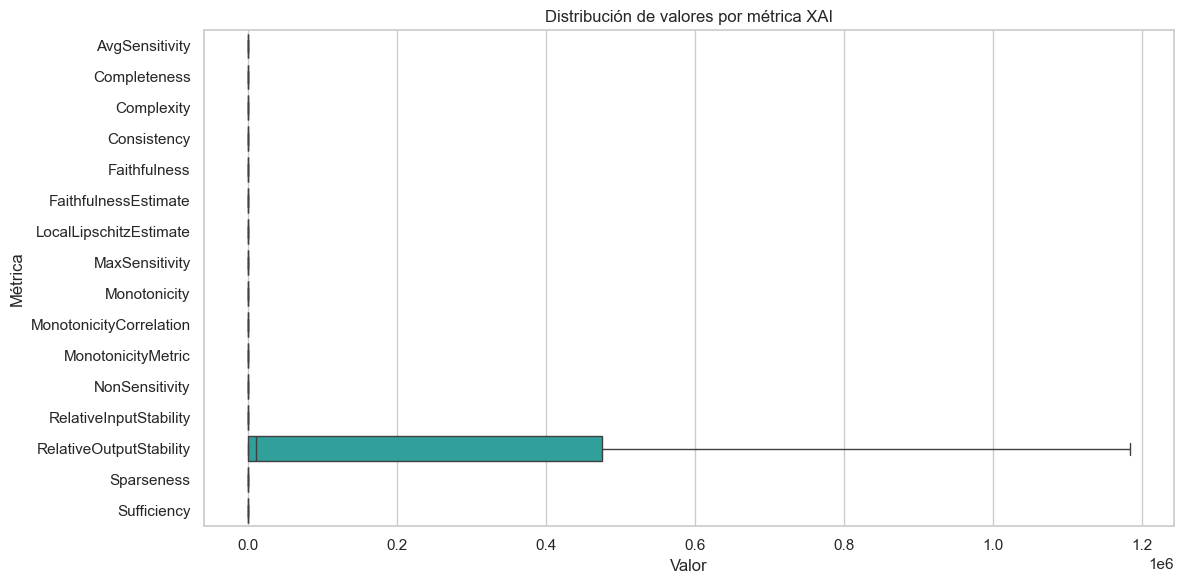

In [12]:
metric_cols_individual = [
    c for c in metric_cols
    if c not in global_metrics
]

plot_df = analysis_df[metric_cols_individual].copy()

for col in metric_cols_individual:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_long = plot_df.melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)

plt.title("Distribución de valores por métrica XAI")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

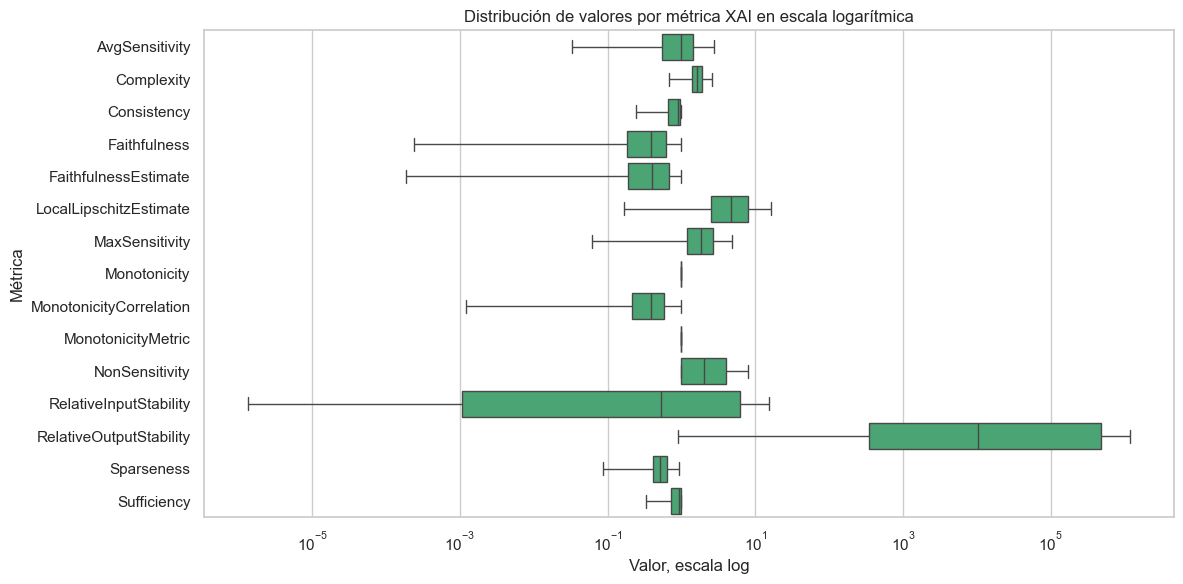

In [13]:
plot_long_positive = plot_long[plot_long["value"] > 0].copy()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long_positive,
    x="value",
    y="metric",
    color="mediumseagreen",
    showfliers=False
)

plt.xscale("log")
plt.title("Distribución de valores por métrica XAI en escala logarítmica")
plt.xlabel("Valor, escala log")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

## Correlación entre métricas

In [14]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

X = analysis_df[metric_cols].dropna(axis=0, how='any')

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=metric_cols,
    index=X.index
)

corr = X_scaled.corr(method='spearman')

corr

,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
AvgSensitivity,1.000000,NaN,0.051373,0.292002,-0.222067,-0.051191,0.104301,0.919764,-0.032231,0.035058,-0.143313,0.220036,0.118216,0.385412,0.065829,0.290680
Completeness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity,0.051373,NaN,1.000000,-0.272378,0.058371,0.095751,0.089584,-0.059638,-0.090200,-0.306795,0.007497,-0.177572,-0.104021,-0.406046,-0.764473,0.191453
Consistency,0.292002,NaN,-0.272378,1.000000,-0.323458,-0.089897,0.012970,0.332031,-0.253041,0.218953,-0.217772,0.330930,-0.276332,0.304020,0.456547,0.149585
Faithfulness,-0.222067,NaN,0.058371,-0.323458,1.000000,0.081146,-0.057747,-0.225563,0.070938,-0.123161,0.202602,-0.060489,0.044776,-0.120798,-0.065532,-0.309301
FaithfulnessEstimate,-0.051191,NaN,0.095751,-0.089897,0.081146,1.000000,-0.038062,-0.061199,0.053885,-0.057666,0.074356,-0.068420,0.010990,-0.027563,-0.048982,0.061173
LocalLipschitzEstimate,0.104301,NaN,0.089584,0.012970,-0.057747,-0.038062,1.000000,-0.042276,-0.062561,-0.147223,0.036050,0.043112,0.093332,0.061639,-0.118611,-0.015286
MaxSensitivity,0.919764,NaN,-0.059638,0.332031,-0.225563,-0.061199,-0.042276,1.000000,0.026888,0.102462,-0.139338,0.186408,0.100091,0.355661,0.124588,0.276535
Monotonicity,-0.032231,NaN,-0.090200,-0.253041,0.070938,0.053885,-0.062561,0.026888,1.000000,0.059104,0.055617,0.238003,-0.104350,-0.011218,0.097799,-0.073324
MonotonicityCorrelation,0.035058,NaN,-0.306795,0.218953,-0.123161,-0.057666,-0.147223,0.102462,0.059104,1.000000,-0.022443,0.047556,-0.067859,0.083958,0.252855,0.144590


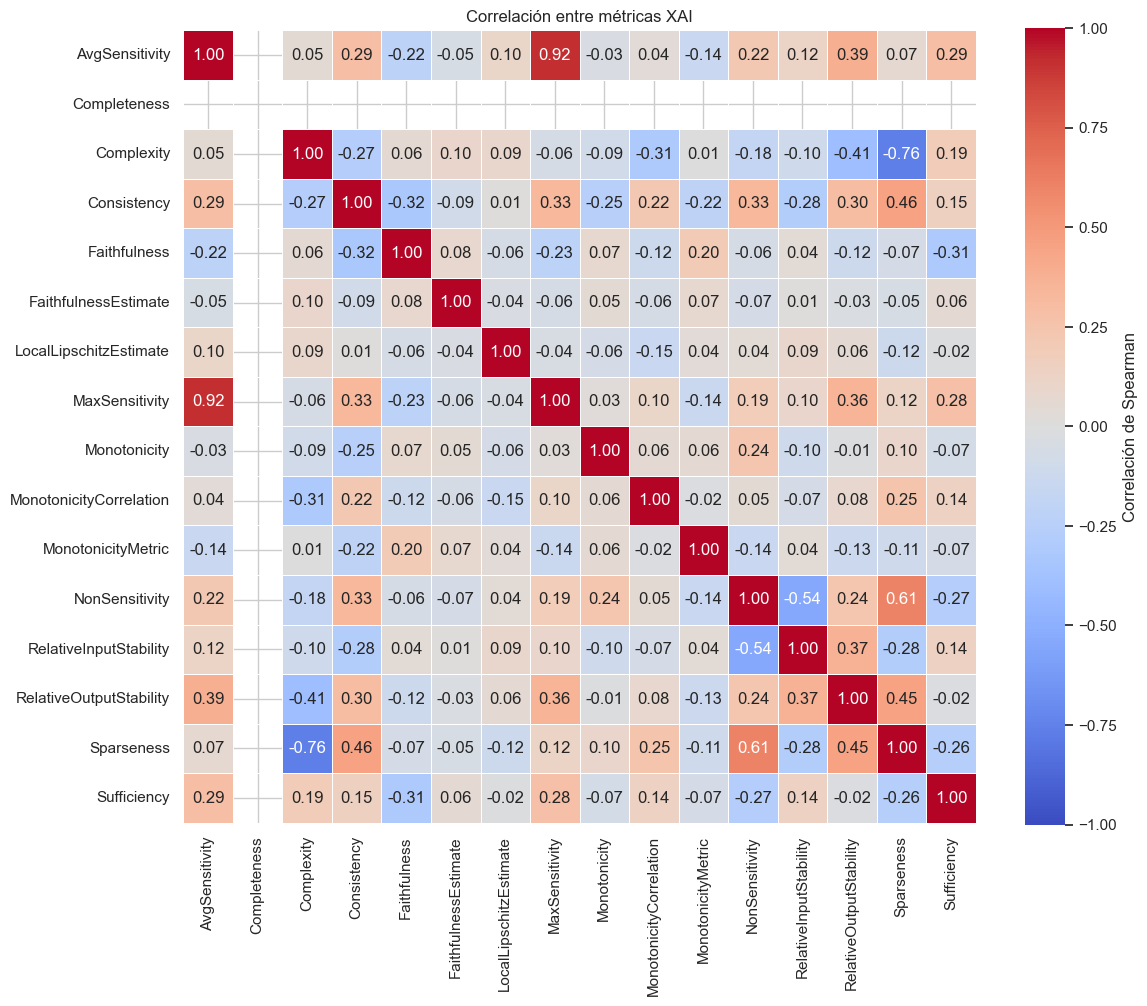

In [15]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas XAI")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / "correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
corr_pairs = (
    corr.where(~pd.DataFrame(
        [[i >= j for j in range(len(corr.columns))] for i in range(len(corr.index))],
        index=corr.index,
        columns=corr.columns
    ))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

strong_corr = corr_pairs[
    corr_pairs["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

strong_corr

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.919764,0.919764
25,Complexity,Sparseness,-0.764473,0.764473
97,NonSensitivity,Sparseness,0.608446,0.608446


In [17]:
mean_abs_corr = corr.abs().copy()

for col in mean_abs_corr.columns:
    mean_abs_corr.loc[col, col] = pd.NA

independence_summary = (
    mean_abs_corr.mean(axis=1)
    .sort_values()
    .reset_index()
)

independence_summary.columns = ["metric", "mean_abs_correlation"]

independence_summary

,metric,mean_abs_correlation
0,FaithfulnessEstimate,0.058591
1,LocalLipschitzEstimate,0.065911
2,Monotonicity,0.087797
3,MonotonicityMetric,0.098941
4,MonotonicityCorrelation,0.119263
5,Faithfulness,0.140425
6,Sufficiency,0.161920
7,RelativeInputStability,0.163207
8,Complexity,0.191082
9,AvgSensitivity,0.209391


## Clustering jerárquico de métricas

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [19]:
Path('results').mkdir(exist_ok=True)

corr_cluster = corr.copy()

corr_cluster = corr_cluster.dropna(axis=0, how='all').dropna(axis=1, how='all')

valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics]

corr_cluster = corr_cluster.fillna(0)

distance = 1 - corr_cluster.abs()
np.fill_diagonal(distance.values, 0)

linkage_matrix = linkage(
    squareform(distance),
    method='average'
)

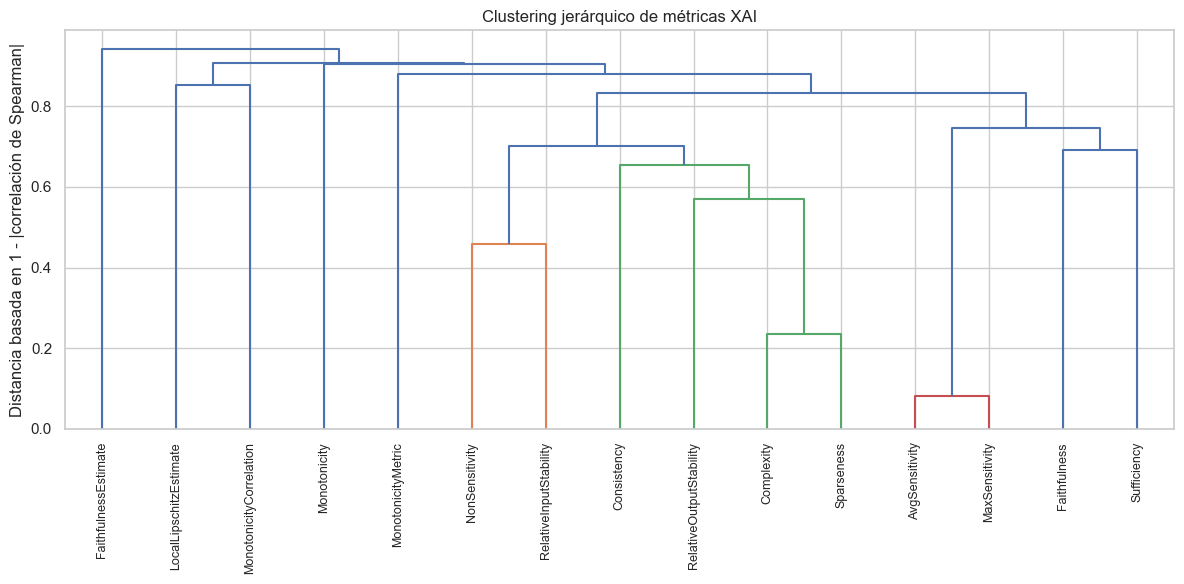

In [20]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=corr_cluster.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas XAI")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(output_dir / "dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

In [21]:
from scipy.stats import kruskal

In [22]:
sns.set_theme(style='whitegrid', context='notebook')

results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(exist_ok=True)

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

factors = ["dataset_name", "model_name", "xai_method"]

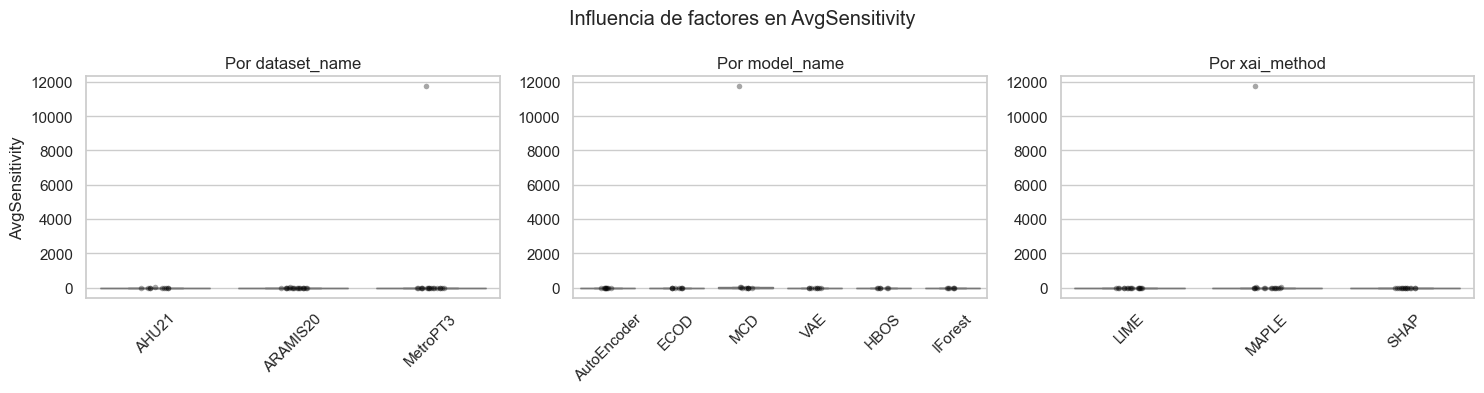

Saltando Completeness: no tiene variabilidad suficiente.


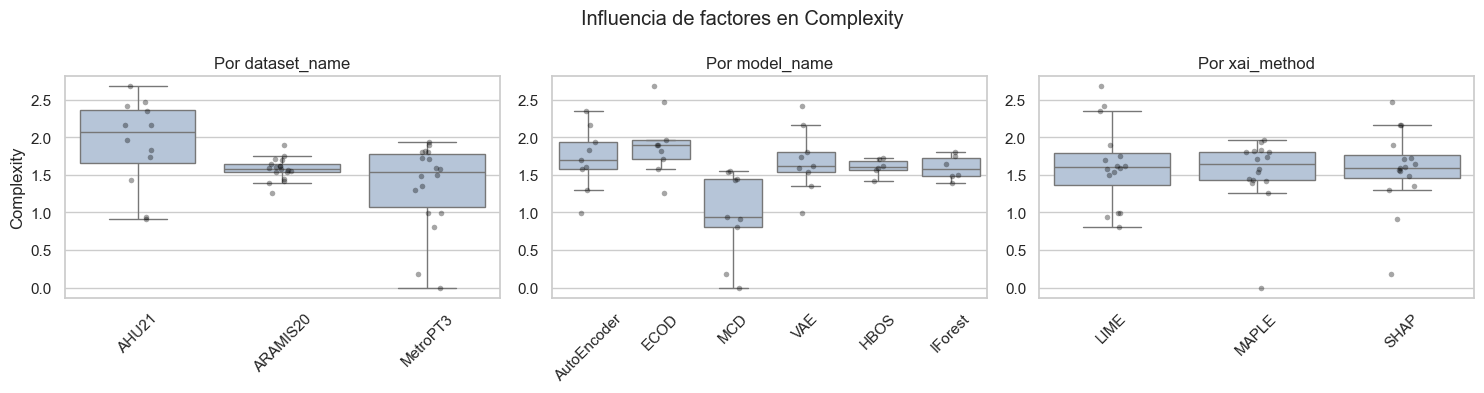

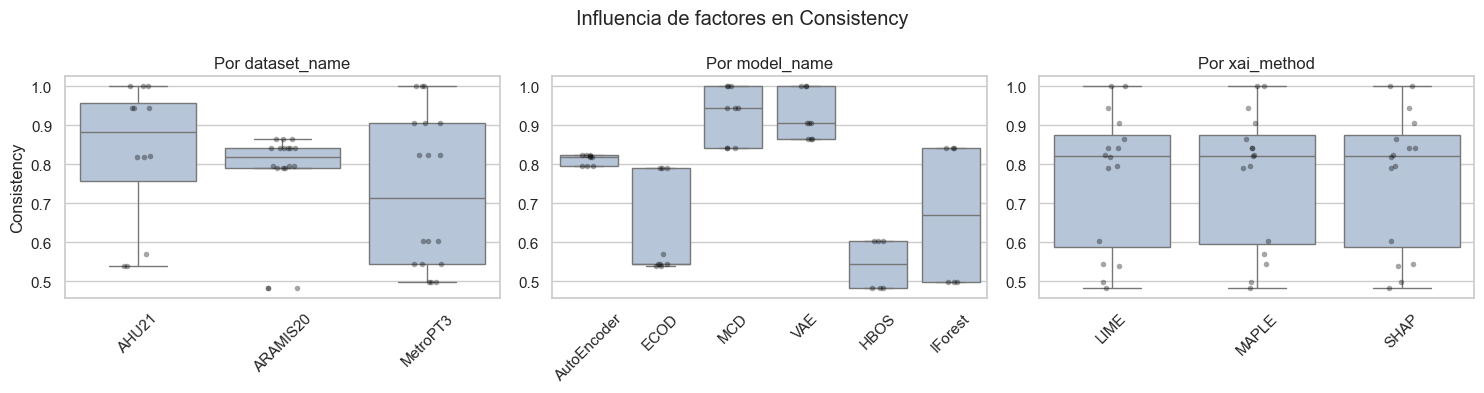

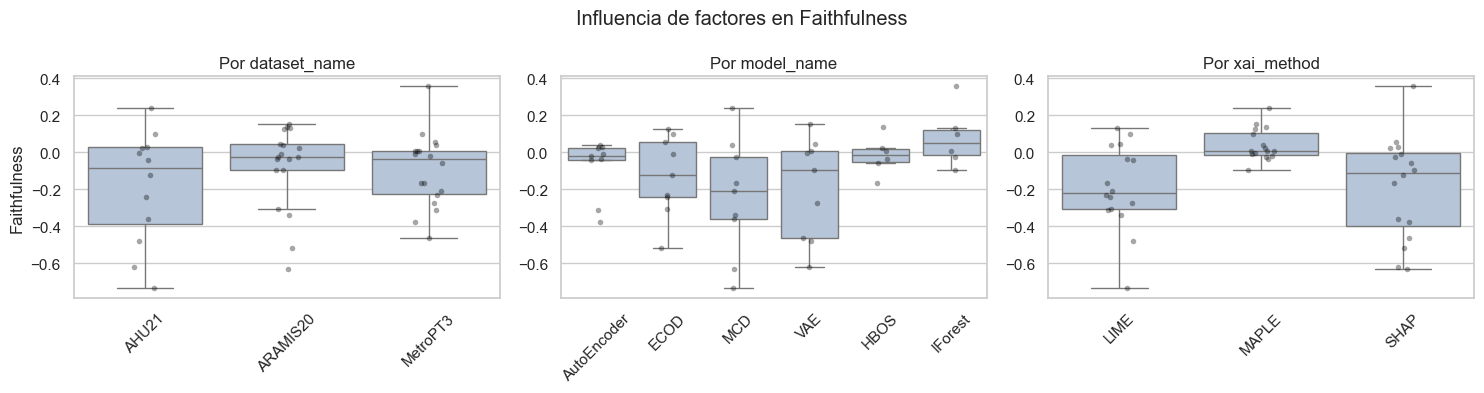

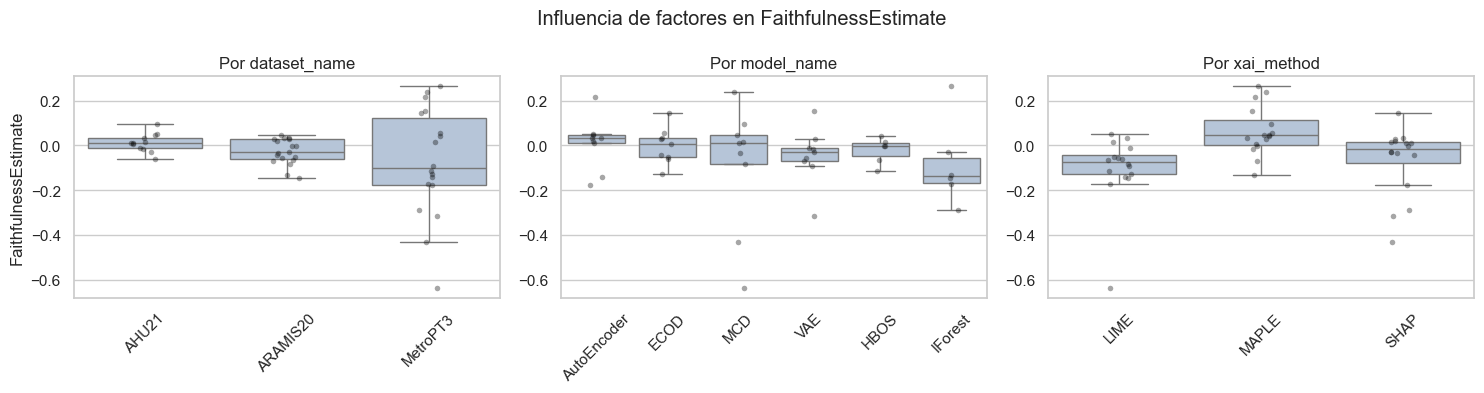

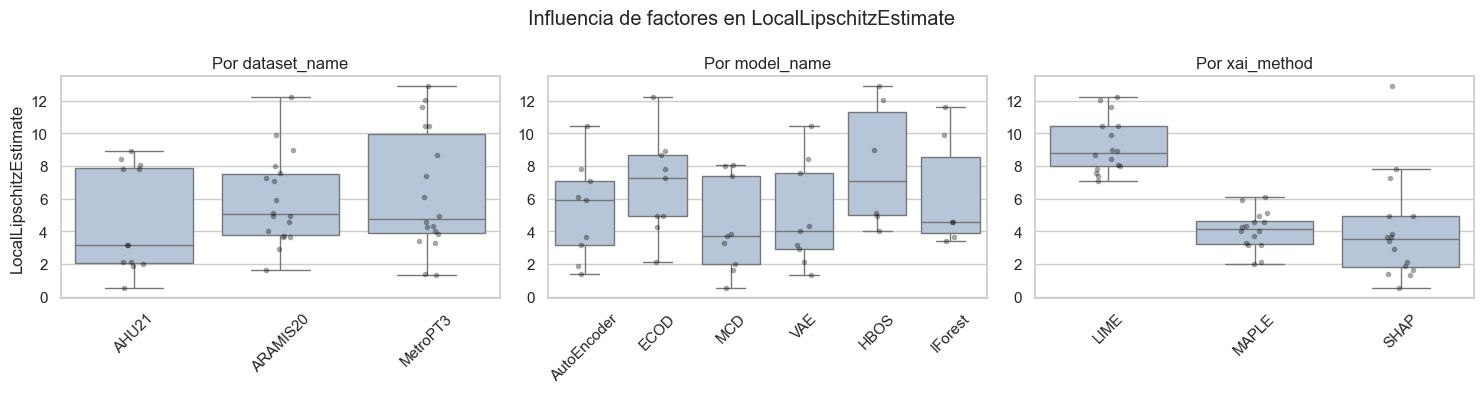

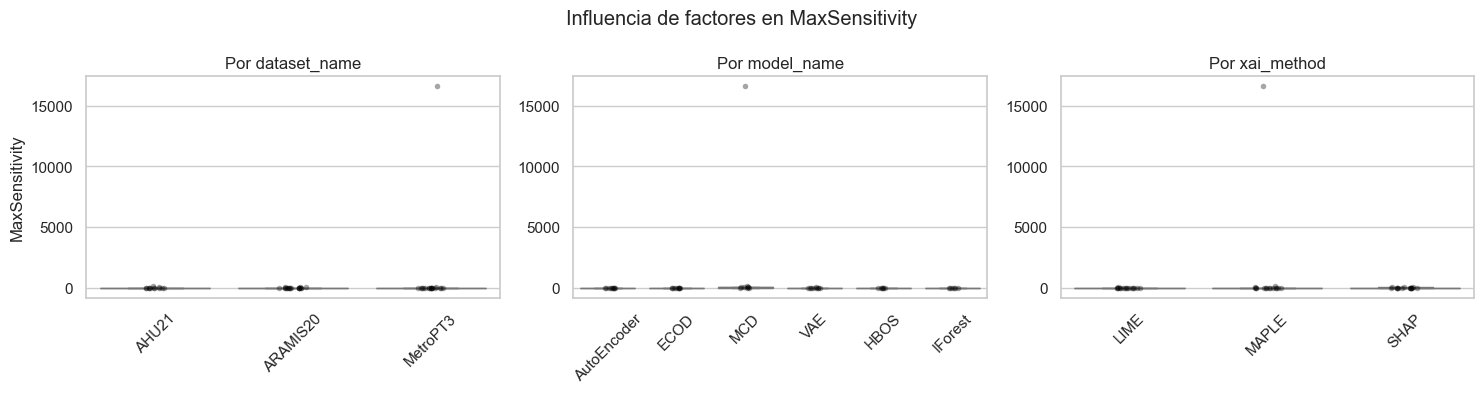

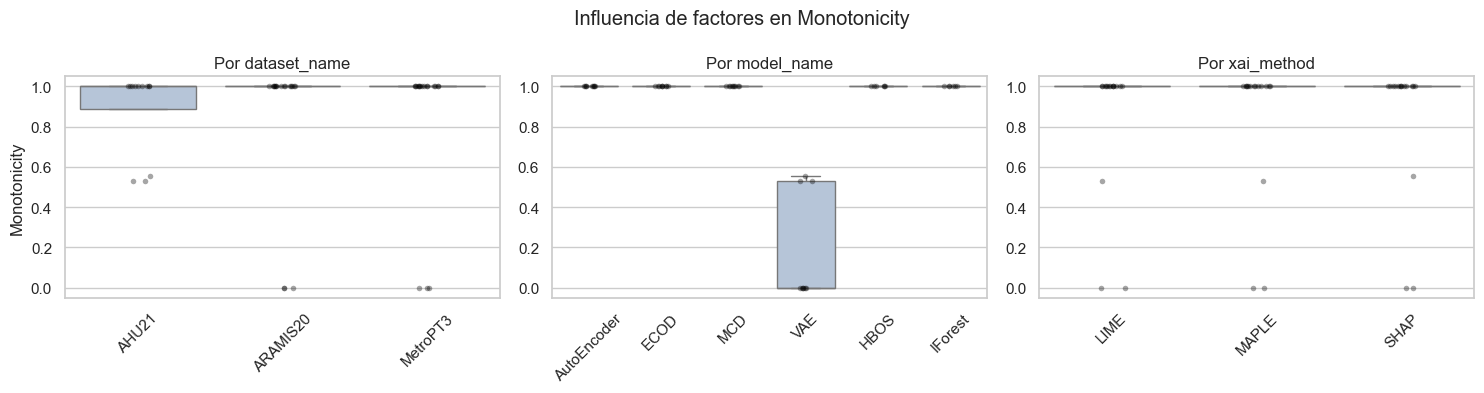

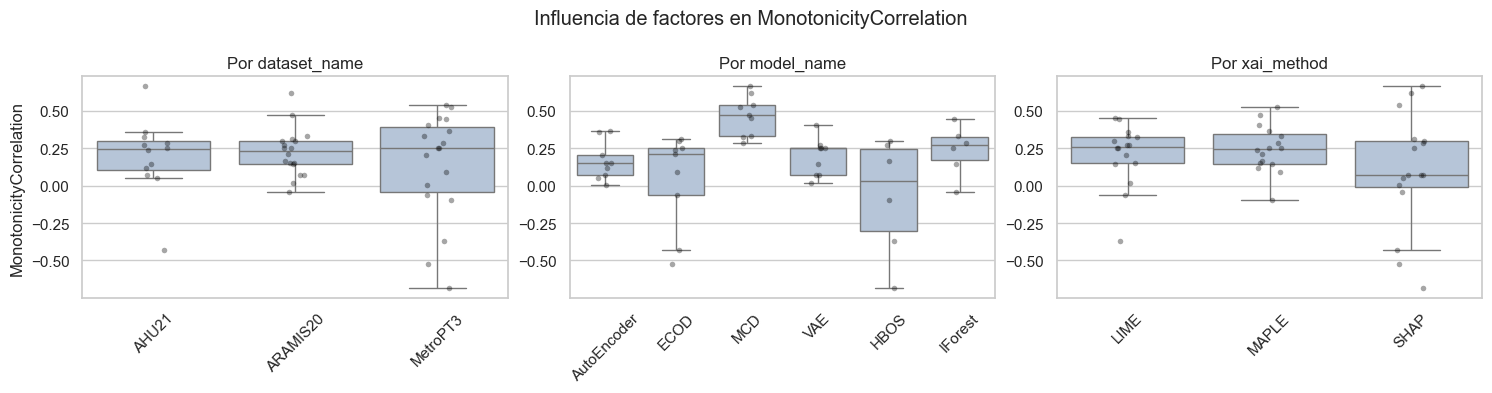

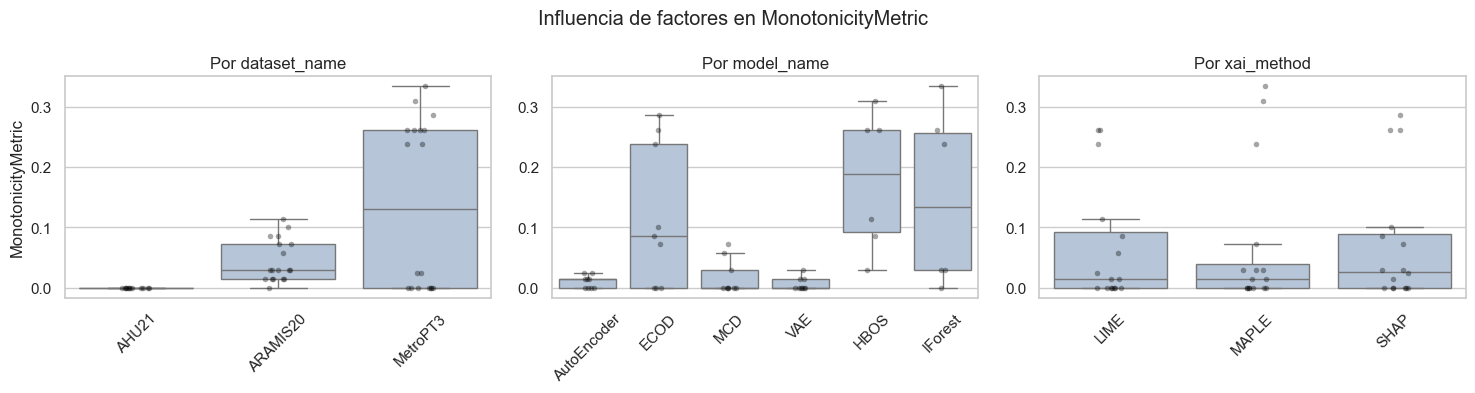

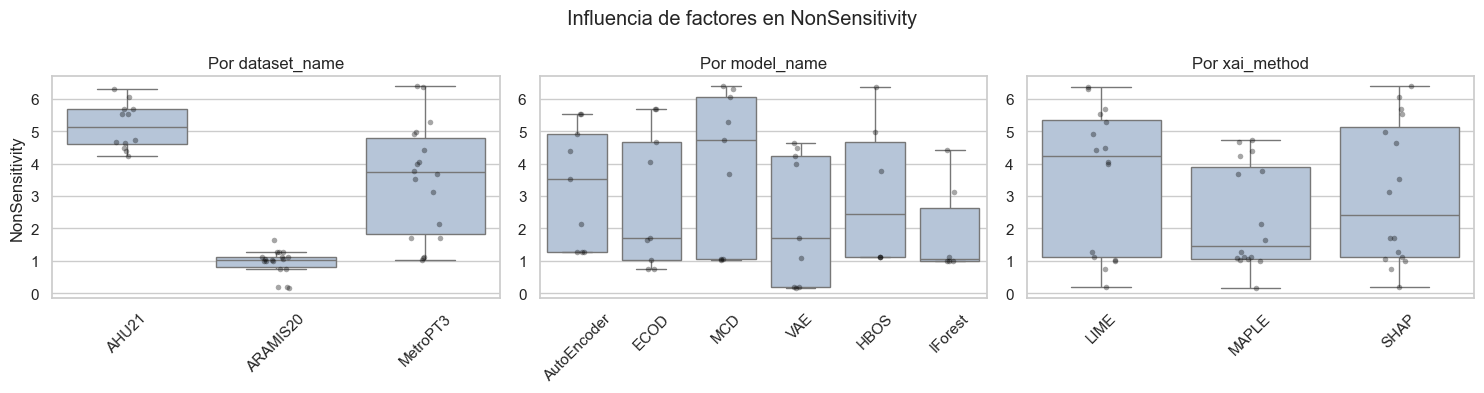

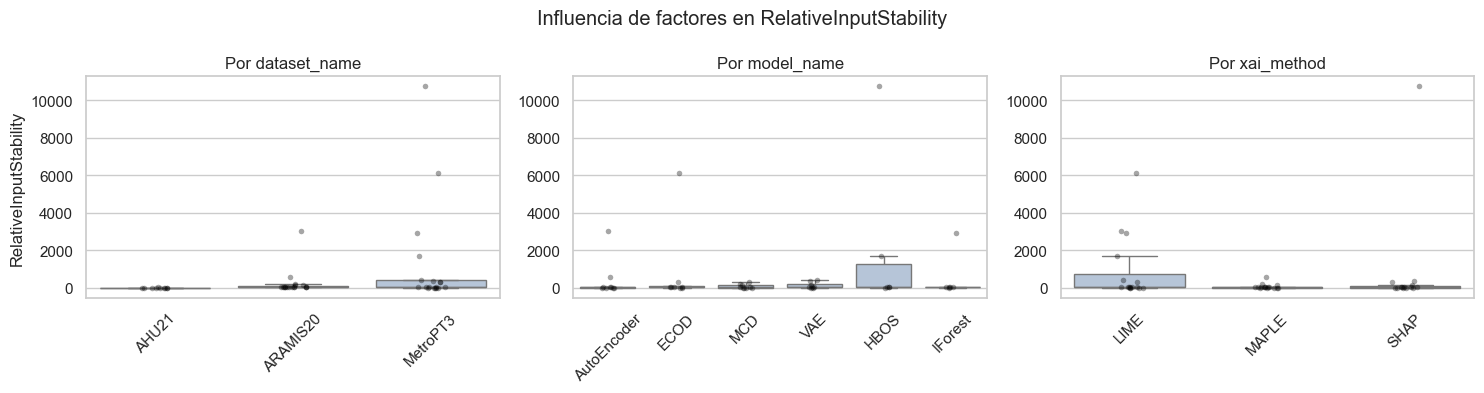

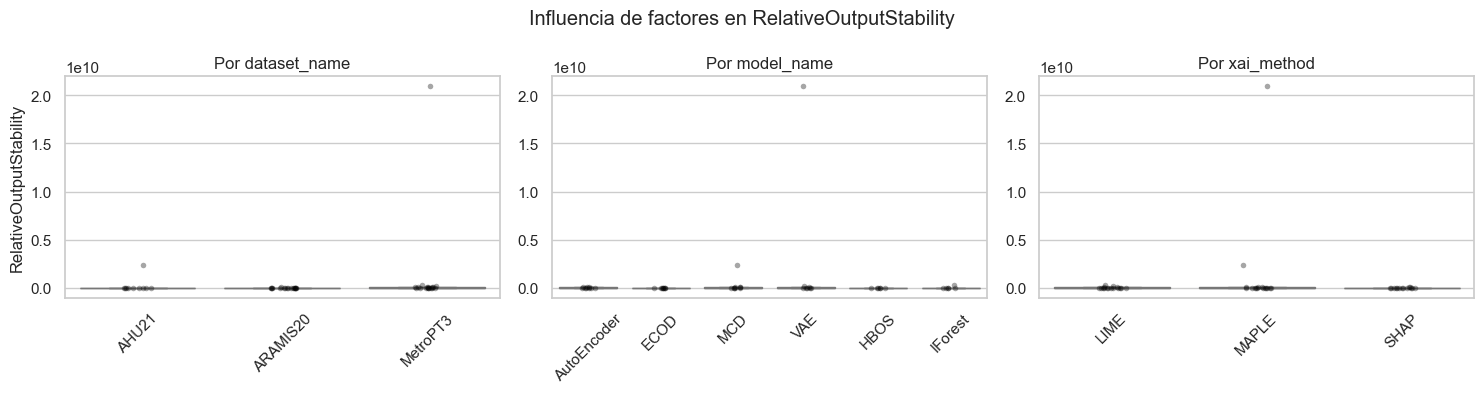

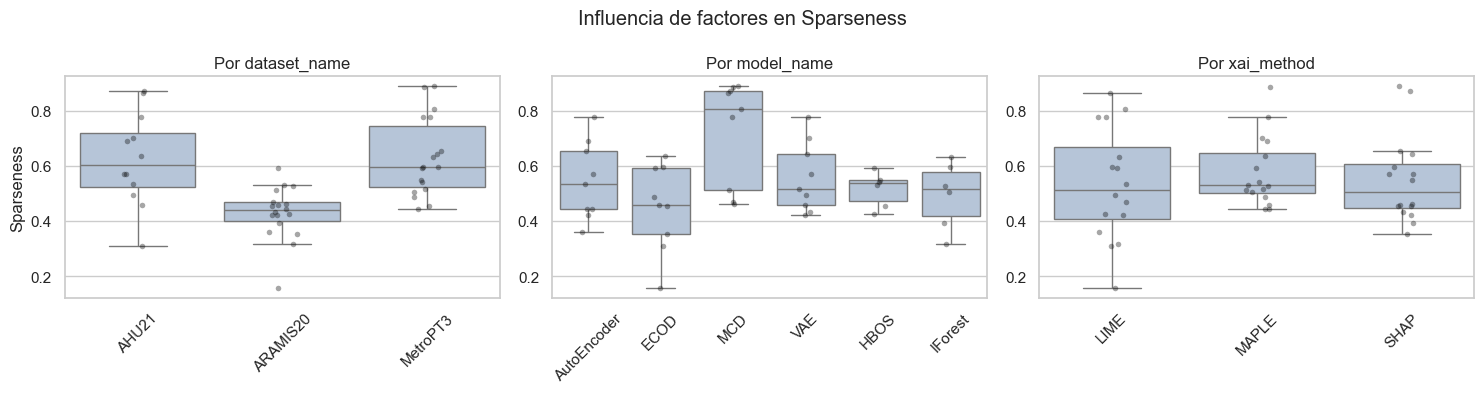

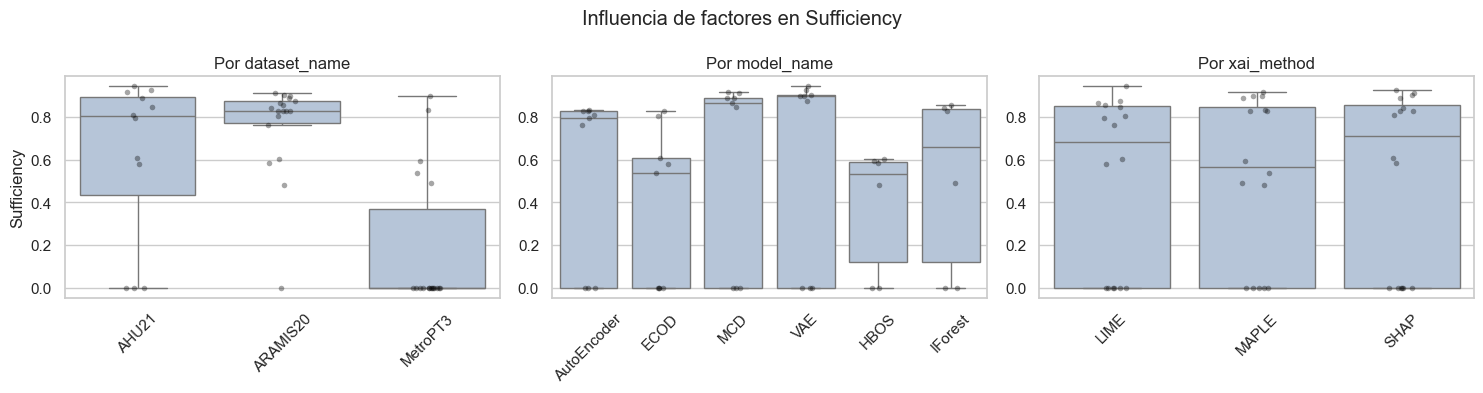

In [23]:
for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        print(f"Saltando {metric}: no tiene variabilidad suficiente.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric}")
    plt.tight_layout()
    plt.savefig(results_dir / f"{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [24]:
kruskal_results = []

for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        continue

    for factor in factors:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df = kruskal_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_df

,metric,factor,H,p_value,significant_0.05
7,Consistency,model_name,1588.267523,0.000000e+00,True
22,Monotonicity,model_name,2158.539160,0.000000e+00,True
30,NonSensitivity,dataset_name,1800.652996,0.000000e+00,True
17,LocalLipschitzEstimate,xai_method,1149.035944,3.090402e-250,True
39,Sparseness,dataset_name,793.320781,5.402333e-173,True
4,Complexity,model_name,756.512843,2.951806e-161,True
42,Sufficiency,dataset_name,738.491413,4.351381e-161,True
33,RelativeInputStability,dataset_name,674.537953,3.356948e-147,True
40,Sparseness,model_name,515.096282,4.399891e-109,True
25,MonotonicityCorrelation,model_name,378.587977,1.219471e-79,True


In [25]:
kruskal_summary = kruskal_df.copy()

kruskal_summary["p_value"] = kruskal_summary["p_value"].round(4)
kruskal_summary["H"] = kruskal_summary["H"].round(3)

kruskal_summary

,metric,factor,H,p_value,significant_0.05
7,Consistency,model_name,1588.268,0.0000,True
22,Monotonicity,model_name,2158.539,0.0000,True
30,NonSensitivity,dataset_name,1800.653,0.0000,True
17,LocalLipschitzEstimate,xai_method,1149.036,0.0000,True
39,Sparseness,dataset_name,793.321,0.0000,True
4,Complexity,model_name,756.513,0.0000,True
42,Sufficiency,dataset_name,738.491,0.0000,True
33,RelativeInputStability,dataset_name,674.538,0.0000,True
40,Sparseness,model_name,515.096,0.0000,True
25,MonotonicityCorrelation,model_name,378.588,0.0000,True


In [26]:
kruskal_summary.to_csv(
    results_dir / "kruskal_metric_factors.csv",
    index=False
)

## PCA

In [27]:
from sklearn.decomposition import PCA

In [28]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

X = analysis_df[valid_metric_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.172850,0.172850
1,PC2,0.134932,0.307781
2,PC3,0.116906,0.424687
3,PC4,0.082855,0.507542
4,PC5,0.074487,0.582029
5,PC6,0.068924,0.650953
6,PC7,0.064248,0.715200
7,PC8,0.063441,0.778642
8,PC9,0.060086,0.838727
9,PC10,0.047956,0.886683


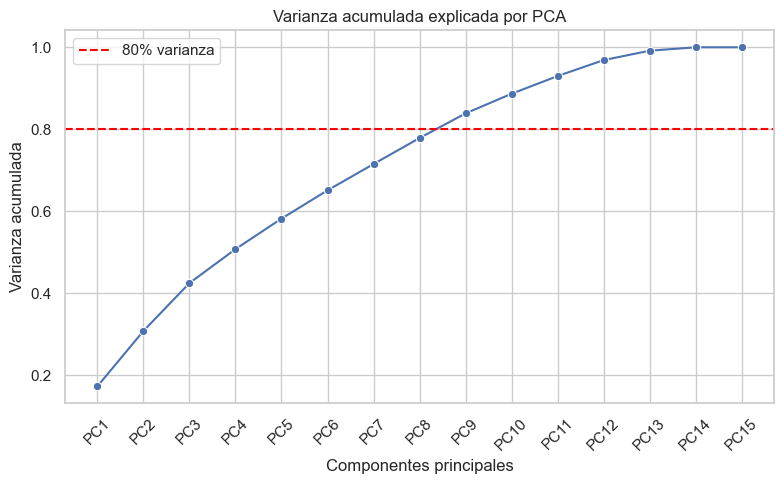

In [29]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_variance",
    marker="o"
)

plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=valid_metric_cols,
    columns=[f"PC{i+1}" for i in range(len(valid_metric_cols))]
)

loadings.iloc[:, :3].sort_values("PC1", key=abs, ascending=False)

,PC1,PC2,PC3
Sparseness,0.515594,-0.091146,-0.302474
Complexity,-0.475054,-0.022946,0.198970
Consistency,0.311526,-0.368955,0.320072
NonSensitivity,0.301327,-0.172142,-0.296329
MaxSensitivity,0.299587,0.503775,0.362516
AvgSensitivity,0.298685,0.504161,0.363091
MonotonicityCorrelation,0.255450,-0.128979,0.057501
Faithfulness,-0.163391,0.359946,-0.316090
MonotonicityMetric,-0.150304,0.230827,-0.173033
Sufficiency,-0.108295,-0.288938,0.451509


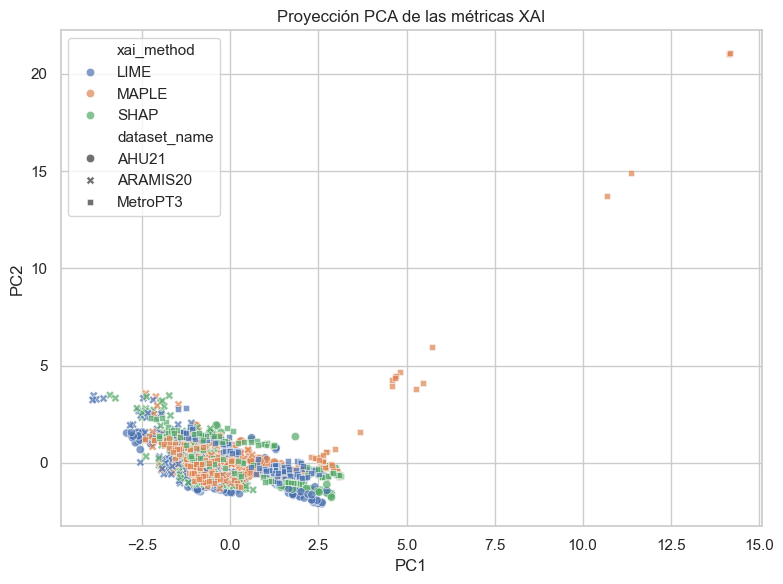

In [31]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df = pca_df.join(analysis_df.loc[X.index, ["dataset_name", "model_name", "xai_method"]])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="xai_method",
    style="dataset_name",
    alpha=0.7
)

plt.title("Proyección PCA de las métricas XAI")
plt.tight_layout()
plt.savefig(output_dir / "pca_metrics_projection.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis de métricas agregadas

In [32]:
matrix_path = Path("results/metric_analysis_agg_matrix.csv")
analysis_agg_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'xai_method']

results_dir = Path("results/conclusions_agg_results")
results_dir.mkdir(exist_ok=True)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


## Análisis descriptivo de las métricas

In [33]:
metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors='coerce')

summary_agg = analysis_agg_df[metric_cols_agg].describe().T

summary_agg['missing'] = analysis_agg_df[metric_cols_agg].isna().sum()
summary_agg['missing_pct'] = analysis_agg_df[metric_cols_agg].isna().mean() * 100
summary_agg['std'] = analysis_agg_df[metric_cols_agg].std()
summary_agg['range'] = summary_agg['max'] - summary_agg['min']
summary_agg['n_unique'] = analysis_agg_df[metric_cols_agg].nunique(dropna=True)

summary_agg = summary_agg[
    ['mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'n_unique']
].sort_values('std', ascending=False)

summary_agg

,mean,std,min,max,range,missing,missing_pct,n_unique
RelativeOutputStability,5.177983e+08,3.097231e+09,2.903308e+01,2.093812e+10,2.093812e+10,2,4.166667,46
MaxSensitivity,3.515618e+02,2.393816e+03,8.099279e-01,1.659008e+04,1.658927e+04,0,0.000000,48
RelativeInputStability,5.870946e+02,1.870975e+03,1.321422e-04,1.072343e+04,1.072343e+04,2,4.166667,46
AvgSensitivity,2.573590e+02,1.728654e+03,5.987122e-01,1.172666e+04,1.172606e+04,2,4.166667,46
LocalLipschitzEstimate,5.772993e+00,3.251282e+00,5.559809e-01,1.286683e+01,1.231085e+01,0,0.000000,48
NonSensitivity,2.961409e+00,2.045052e+00,1.714286e-01,6.380952e+00,6.209524e+00,0,0.000000,39
Complexity,1.581329e+00,5.004896e-01,-1.000089e-12,2.675365e+00,2.675365e+00,0,0.000000,48
Sufficiency,5.053332e-01,3.947991e-01,0.000000e+00,9.428571e-01,9.428571e-01,0,0.000000,32
Monotonicity,8.461310e-01,3.422137e-01,0.000000e+00,1.000000e+00,1.000000e+00,0,0.000000,4
SensitivityN,-1.212427e-01,2.900134e-01,-9.636733e-01,2.995004e-01,1.263174e+00,0,0.000000,48


In [34]:
sns.set_theme(style='whitegrid', context='notebook')

summary_agg_plot = summary_agg.copy()

summary_agg_plot = summary_agg_plot.drop(index=global_metrics, errors='ignore')

summary_agg_plot = summary_agg_plot.sort_values('std', ascending=False)

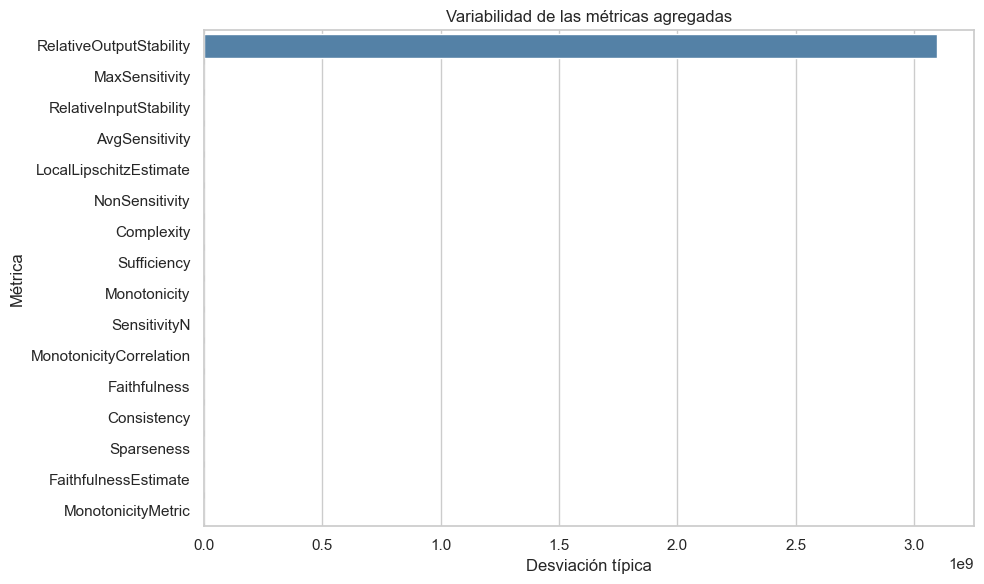

In [35]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

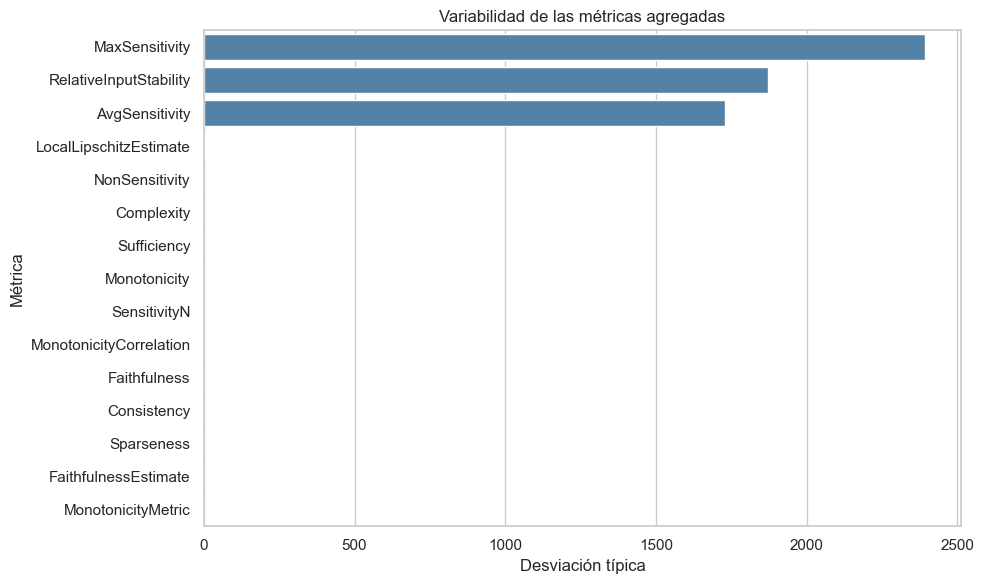

In [36]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

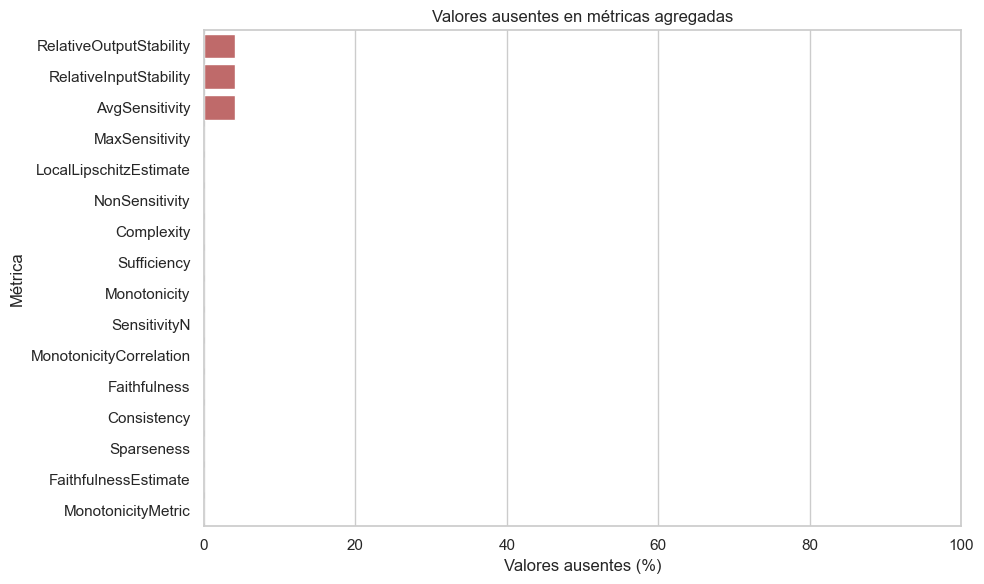

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.sort_values("missing_pct", ascending=False).reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)
plt.title("Valores ausentes en métricas agregadas")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_missing.png", dpi=300, bbox_inches="tight")
plt.show()

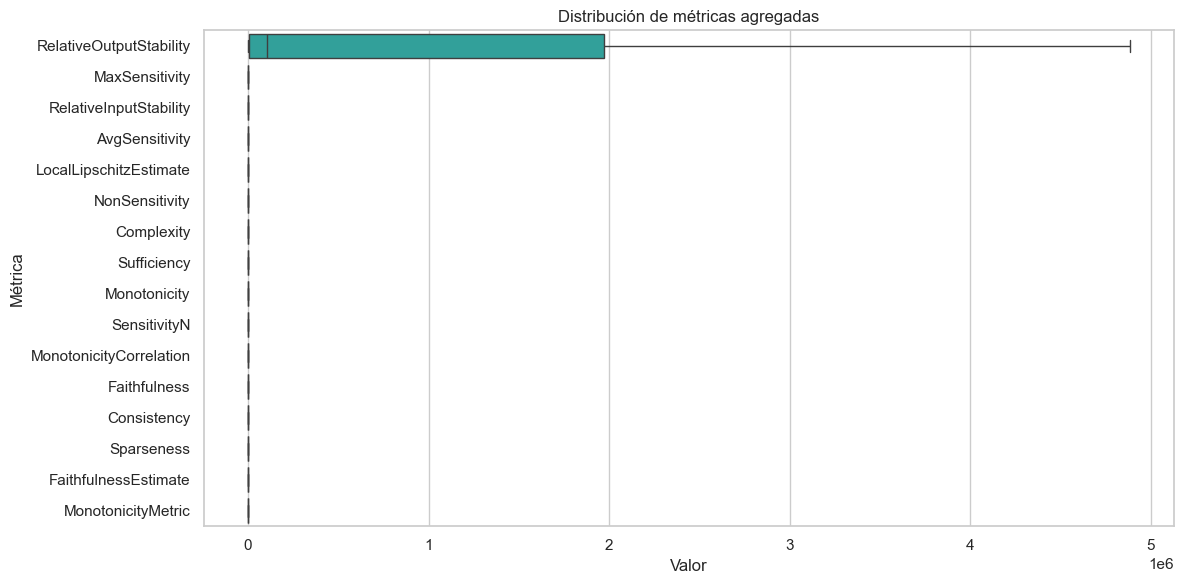

In [38]:
plot_long_agg = analysis_agg_df[summary_plot_agg.index].melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

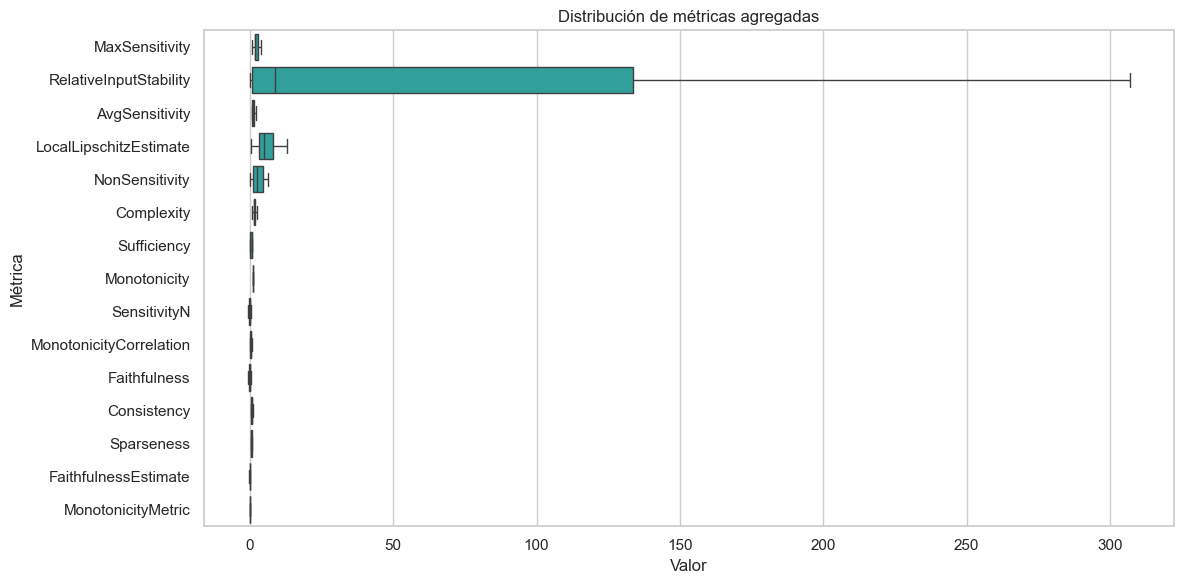

In [39]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

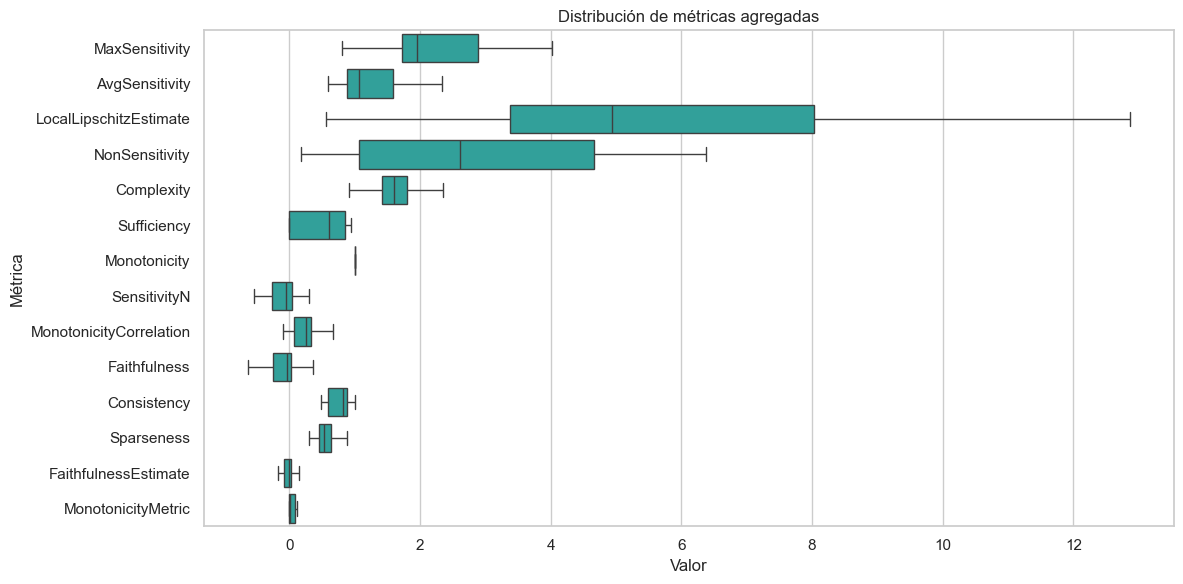

In [40]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability', 'RelativeInputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlación entre métricas

In [41]:
valid_metric_cols_agg = [
    c for c in metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

excluded_constant_agg = [
    c for c in metric_cols_agg
    if c not in valid_metric_cols_agg
]

print("Métricas excluidas por ser constantes o no tener variación:")
print(excluded_constant_agg)

X_agg = analysis_agg_df[valid_metric_cols_agg]

corr_agg = X_agg.corr(
    method="spearman",
    min_periods=5
)

corr_agg

Métricas excluidas por ser constantes o no tener variación:
['Completeness']


,AvgSensitivity,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
AvgSensitivity,1.000000,-0.221092,0.214818,-0.152883,0.064323,-0.161517,0.785261,0.069635,0.202714,0.002294,0.235486,0.025964,0.264261,-0.050632,0.239716,0.178145
Complexity,-0.221092,1.000000,-0.335338,0.076748,0.374294,0.132762,-0.284629,-0.052156,-0.370278,-0.036572,-0.016615,-0.234906,-0.463583,0.227421,-0.545484,0.204759
Consistency,0.214818,-0.335338,1.000000,-0.298078,-0.084800,-0.317986,0.241889,-0.490468,0.302049,-0.648626,0.093046,-0.100393,0.391557,-0.007234,0.387773,0.357152
Faithfulness,-0.152883,0.076748,-0.298078,1.000000,0.301563,-0.132870,-0.052649,0.084185,-0.133087,0.110562,-0.208660,0.006229,-0.141412,-0.003908,-0.070994,-0.146685
FaithfulnessEstimate,0.064323,0.374294,-0.084800,0.301563,1.000000,-0.212440,0.116153,0.104473,-0.016609,-0.044868,-0.042134,-0.152883,0.067777,0.402953,-0.139492,0.245734
LocalLipschitzEstimate,-0.161517,0.132762,-0.317986,-0.132870,-0.212440,1.000000,-0.444095,0.137619,-0.065132,0.242346,0.060595,0.310392,-0.077767,-0.102149,-0.276270,-0.153125
MaxSensitivity,0.785261,-0.284629,0.241889,-0.052649,0.116153,-0.444095,1.000000,0.121565,0.094008,0.015069,0.167558,-0.044712,0.148813,0.049066,0.347807,0.128030
Monotonicity,0.069635,-0.052156,-0.490468,0.084185,0.104473,0.137619,0.121565,1.000000,0.074920,0.313813,0.225239,-0.140019,-0.196925,0.043131,-0.010543,-0.264142
MonotonicityCorrelation,0.202714,-0.370278,0.302049,-0.133087,-0.016609,-0.065132,0.094008,0.074920,1.000000,-0.229986,-0.006081,-0.174961,0.283256,0.024859,0.225684,0.186882
MonotonicityMetric,0.002294,-0.036572,-0.648626,0.110562,-0.044868,0.242346,0.015069,0.313813,-0.229986,1.000000,-0.387472,0.363297,-0.190759,-0.133871,-0.288569,-0.208583


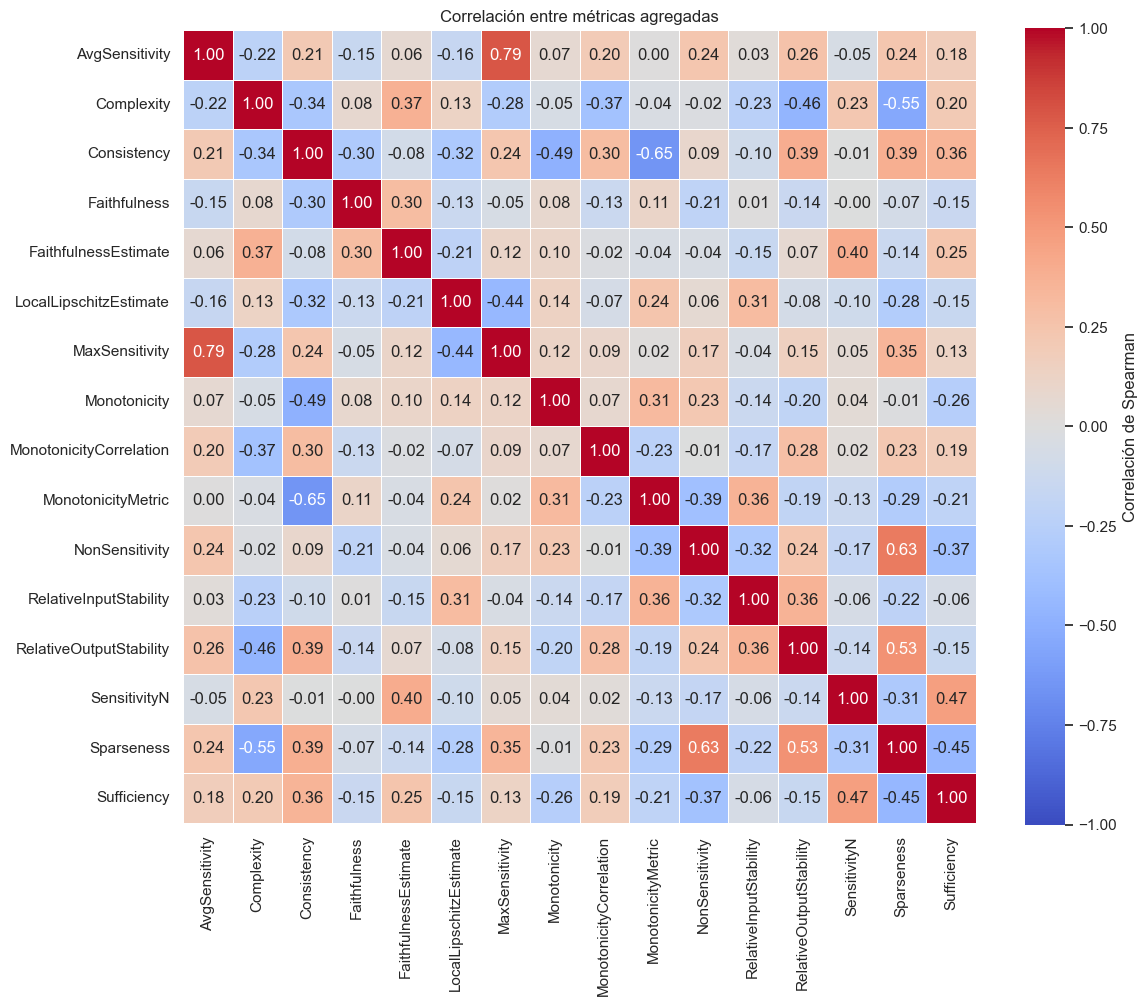

In [42]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_agg,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas agregadas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "agg_correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
corr_pairs_agg = (
    corr_agg.where(
        np.triu(np.ones(corr_agg.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs_agg.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs_agg["abs_corr"] = corr_pairs_agg["spearman_corr"].abs()

strong_corr_agg = corr_pairs_agg[
    corr_pairs_agg["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

strong_corr_agg

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.785261,0.785261
35,Consistency,MonotonicityMetric,-0.648626,0.648626
108,NonSensitivity,Sparseness,0.634342,0.634342


## Clustering jerárquico de métricas

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

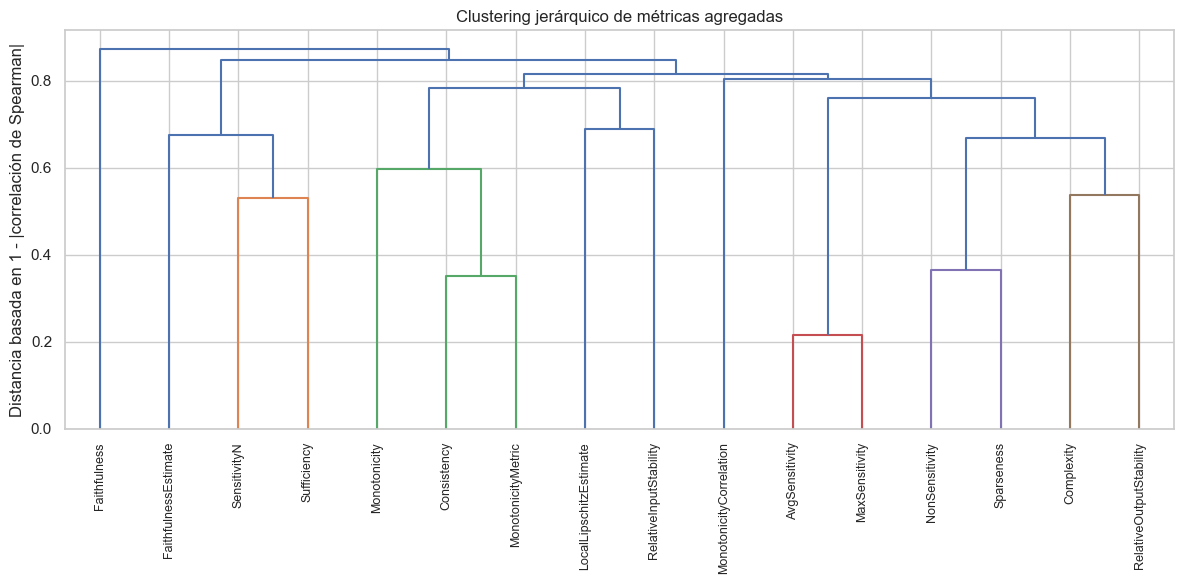

In [45]:
corr_cluster_agg = corr_agg.copy()

corr_cluster_agg = corr_cluster_agg.dropna(axis=0, how="all").dropna(axis=1, how="all")

valid_metrics_agg = corr_cluster_agg.index.intersection(corr_cluster_agg.columns)
corr_cluster_agg = corr_cluster_agg.loc[valid_metrics_agg, valid_metrics_agg]

corr_cluster_agg = corr_cluster_agg.fillna(0)

distance_agg = 1 - corr_cluster_agg.abs()
np.fill_diagonal(distance_agg.values, 0)

linkage_matrix_agg = linkage(
    squareform(distance_agg),
    method="average"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix_agg,
    labels=corr_cluster_agg.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas agregadas")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(results_dir / "agg_dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

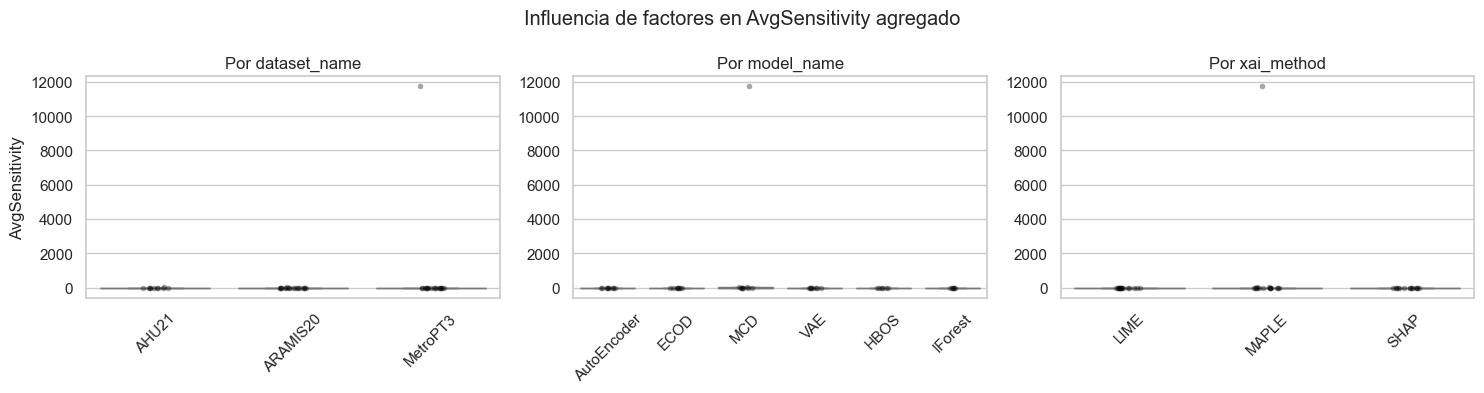

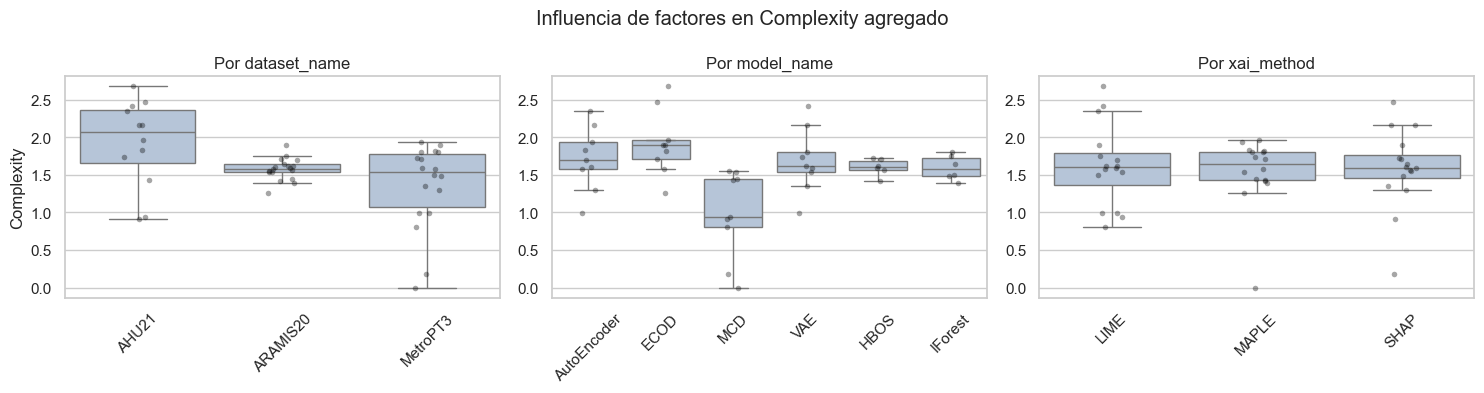

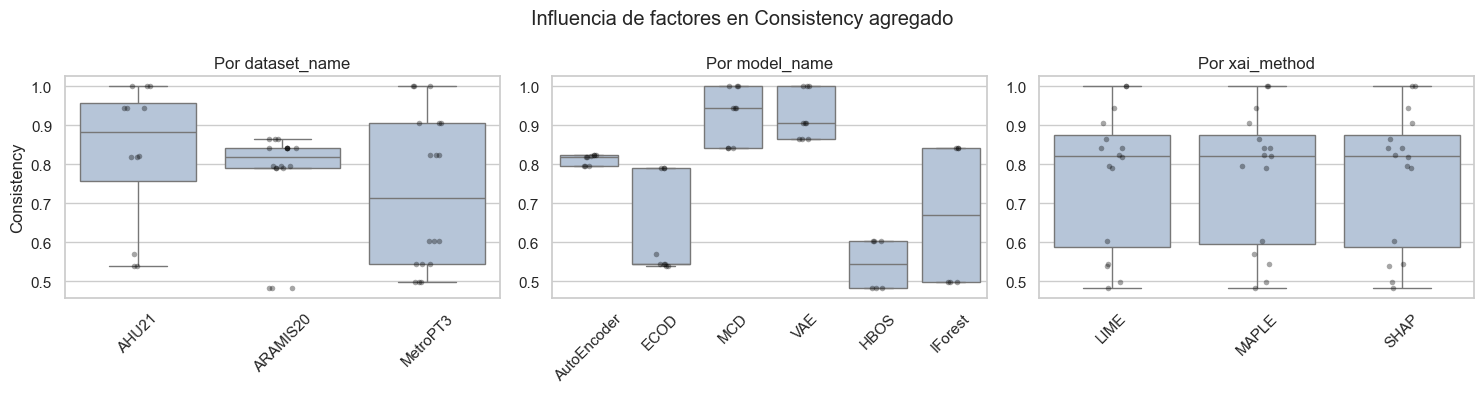

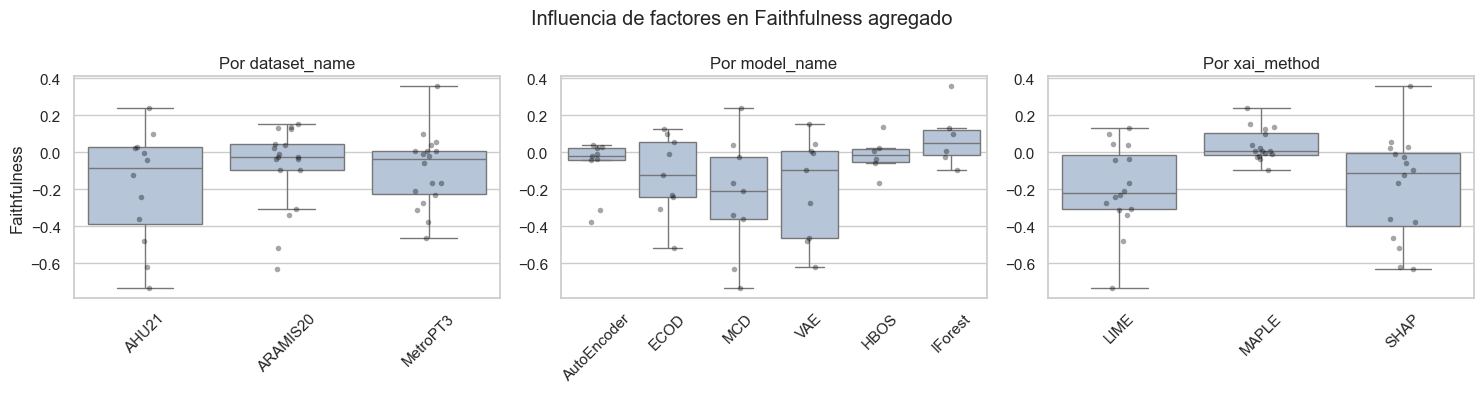

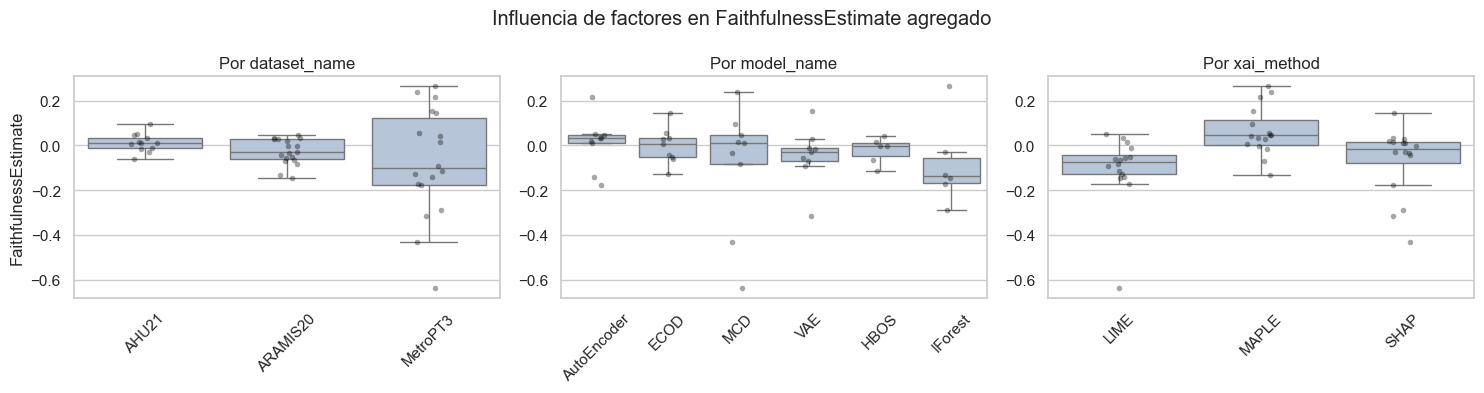

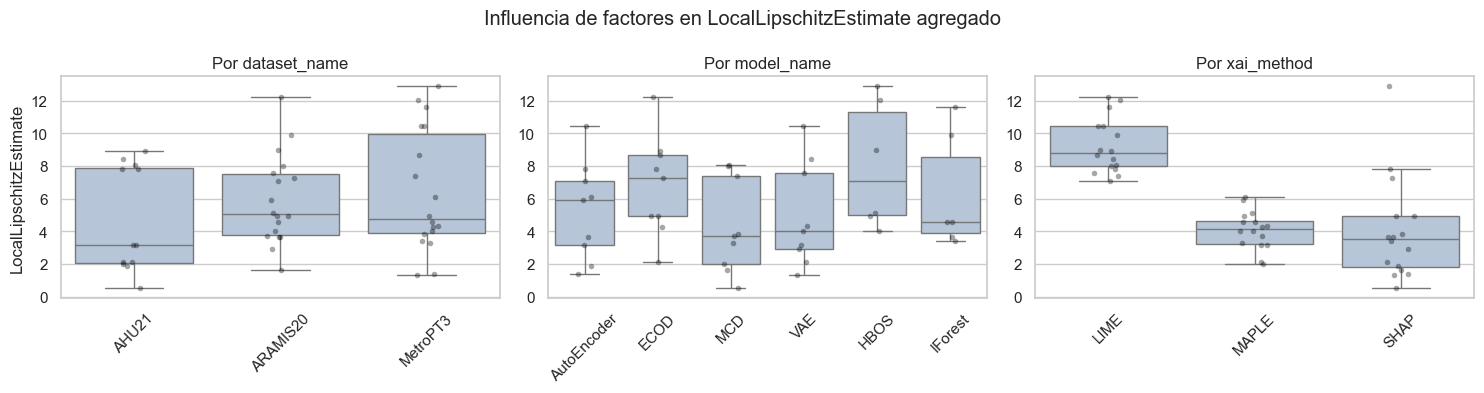

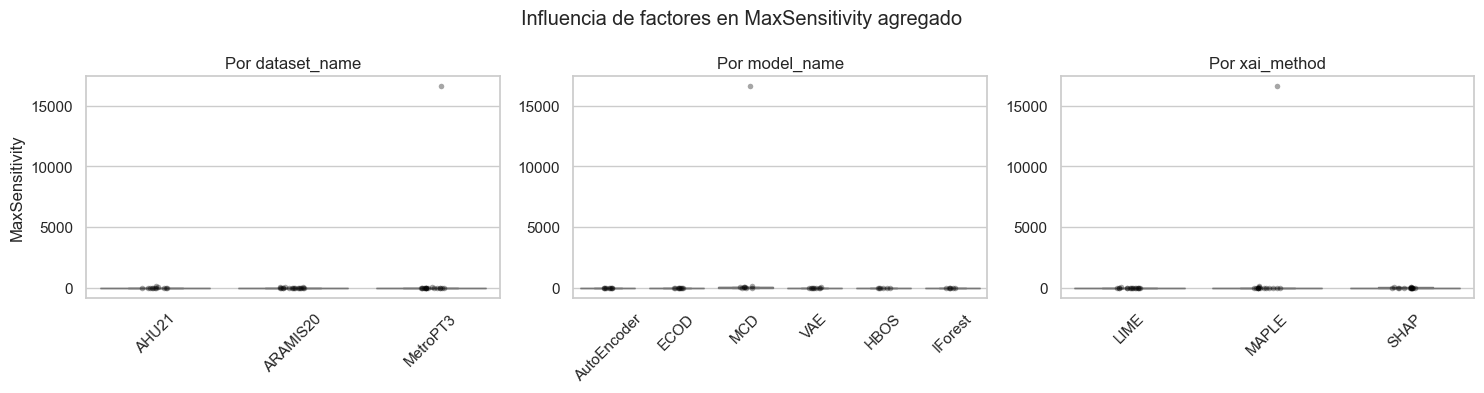

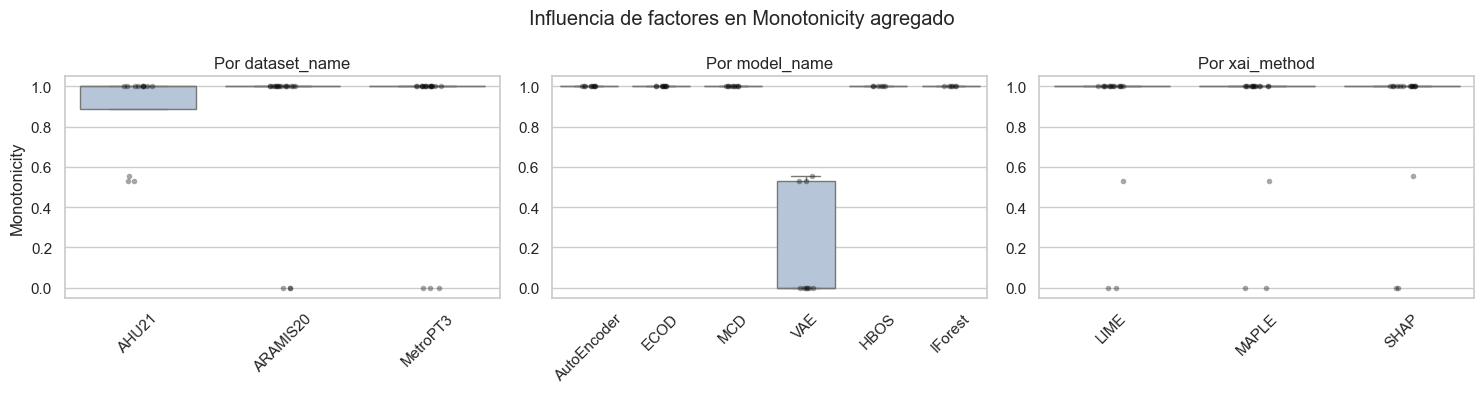

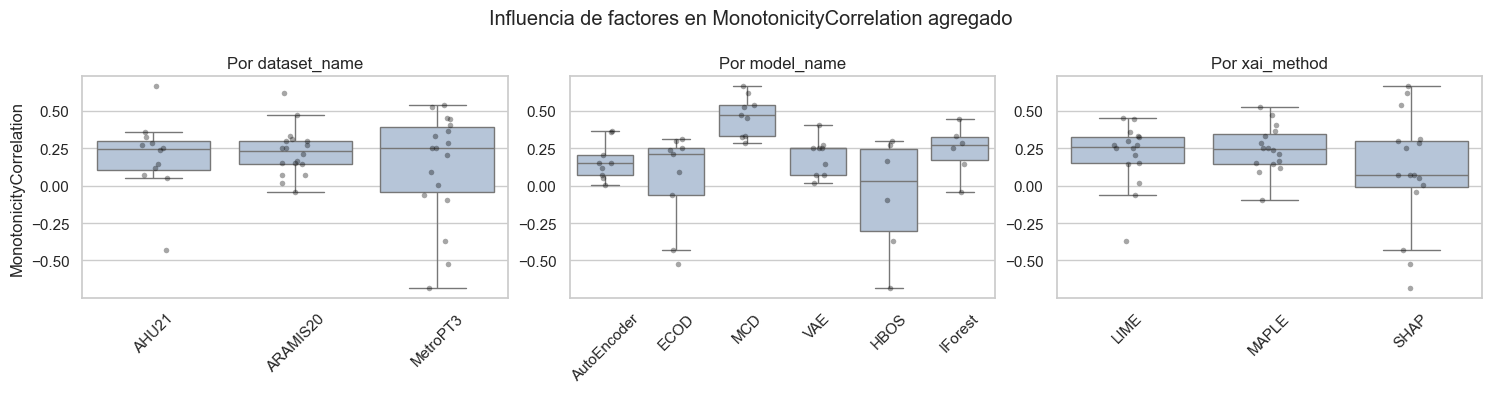

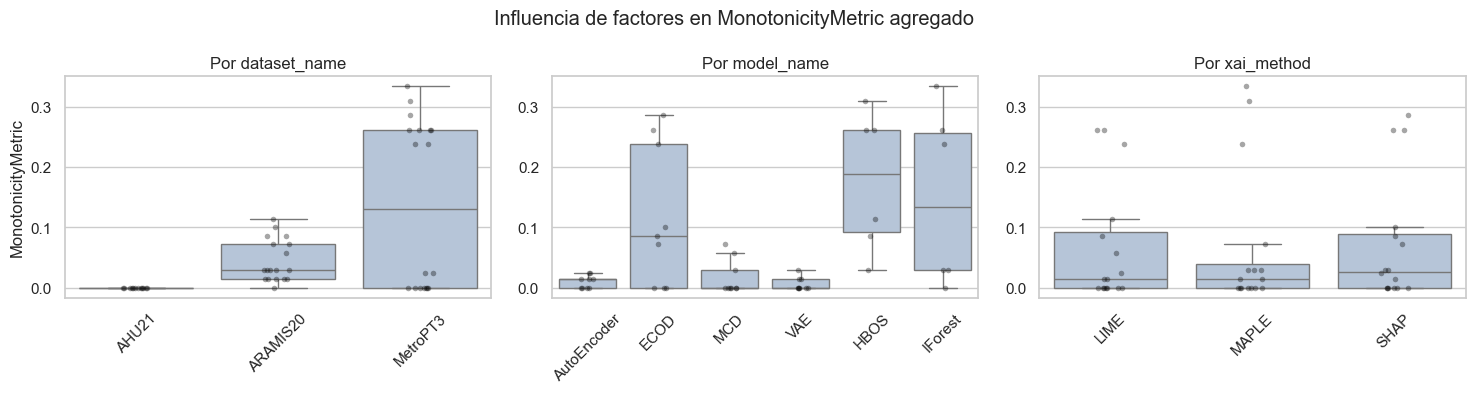

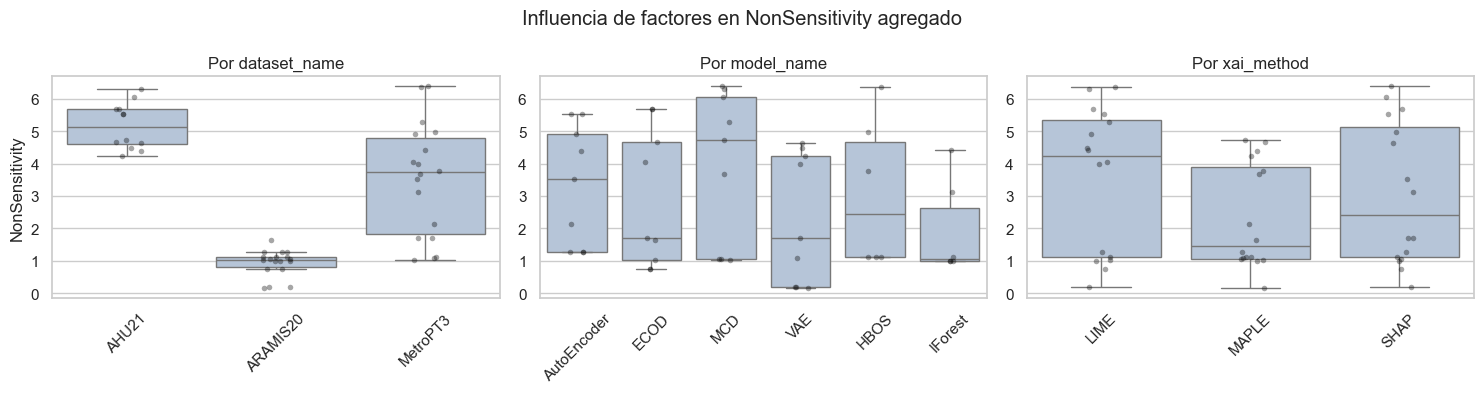

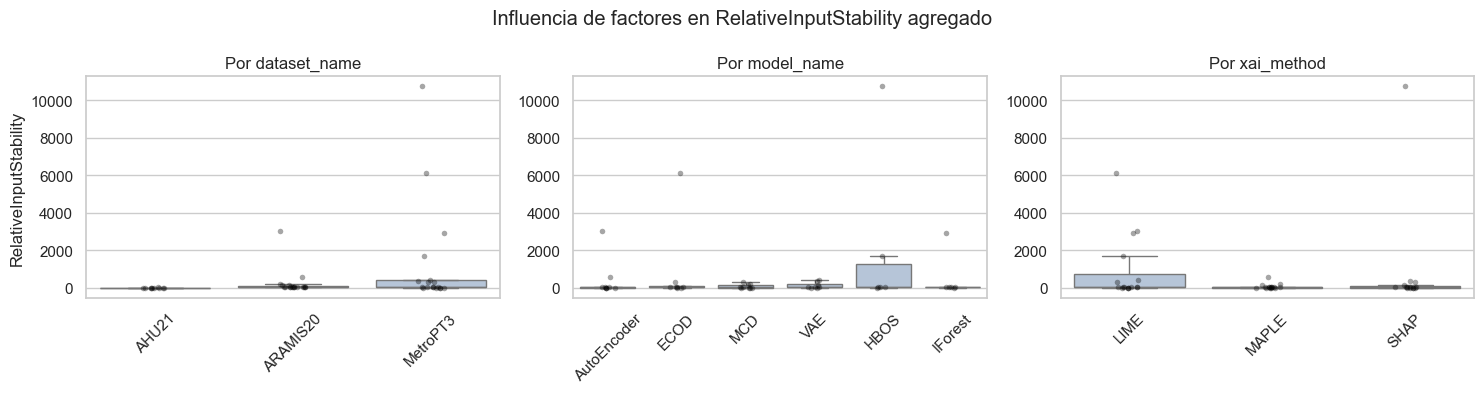

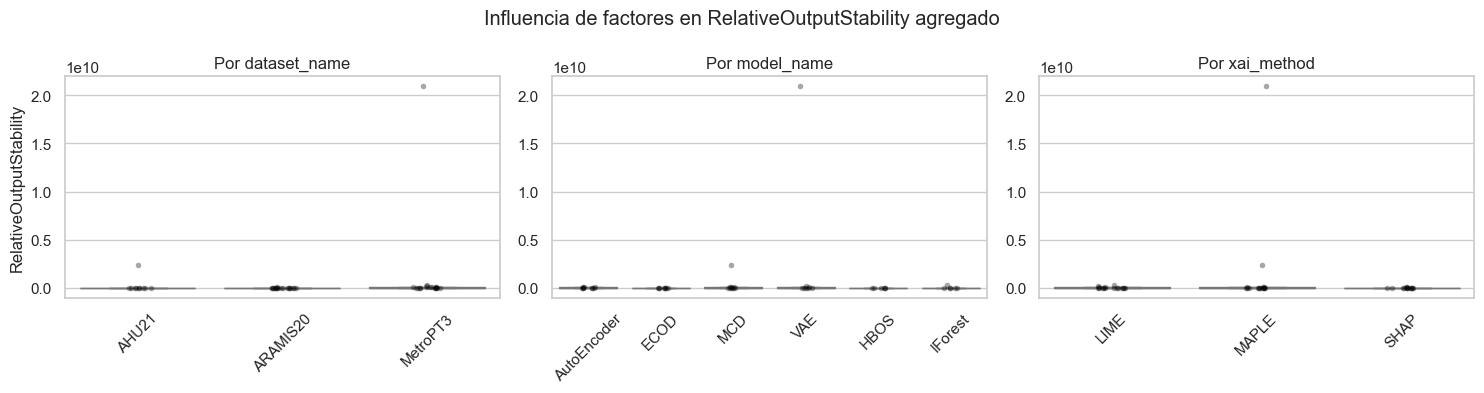

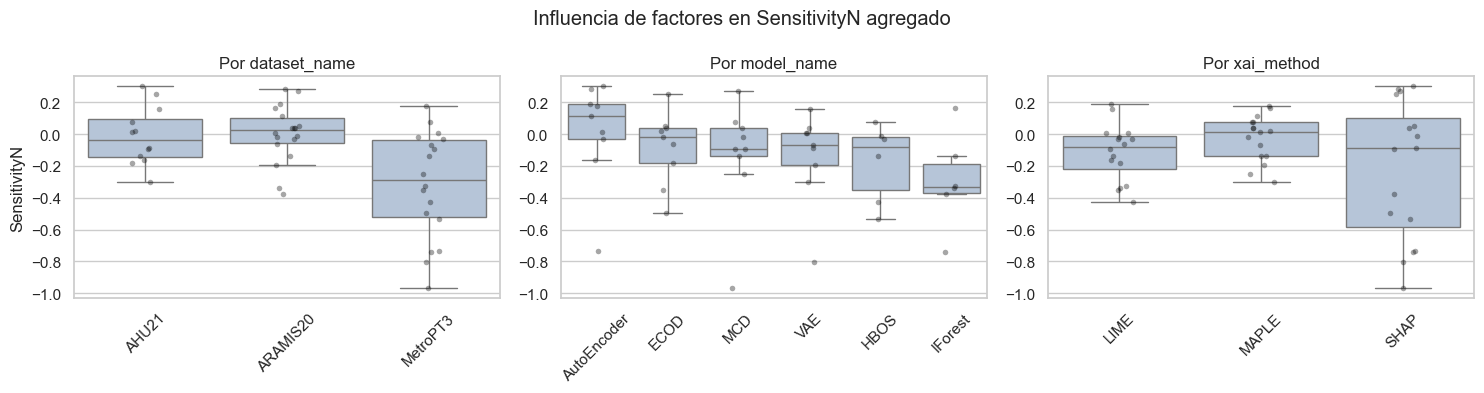

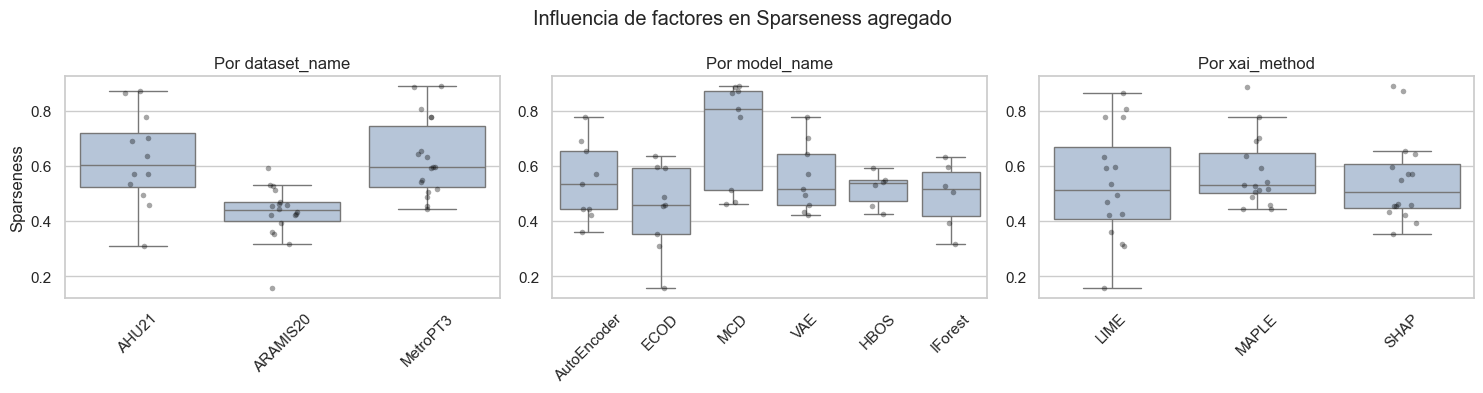

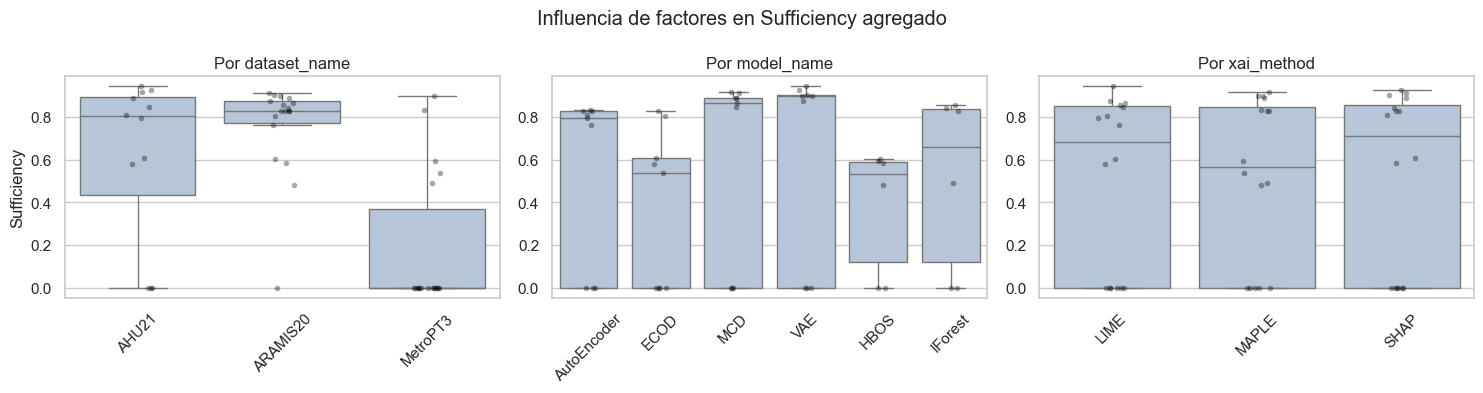

In [46]:
factors_agg = ["dataset_name", "model_name", "xai_method"]

selected_metrics_agg = [
    c for c in valid_metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

for metric in selected_metrics_agg:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors_agg):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors_agg[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric} agregado")
    plt.tight_layout()
    plt.savefig(results_dir / f"agg_{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [47]:
kruskal_results_agg = []

for metric in selected_metrics_agg:
    for factor in factors_agg:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_agg_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results_agg.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_agg_df = pd.DataFrame(kruskal_results_agg)

kruskal_agg_df = kruskal_agg_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_agg_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,46.535966,7.063673e-09,True
30,NonSensitivity,dataset_name,31.305536,1.592536e-07,True
7,Consistency,model_name,37.152289,5.582844e-07,True
17,LocalLipschitzEstimate,xai_method,26.895408,1.444562e-06,True
33,RelativeInputStability,dataset_name,21.294234,2.376927e-05,True
42,Sparseness,dataset_name,20.034722,4.461854e-05,True
27,MonotonicityMetric,dataset_name,17.303361,1.748328e-04,True
45,Sufficiency,dataset_name,16.788934,2.261149e-04,True
14,FaithfulnessEstimate,xai_method,13.915179,9.513873e-04,True
28,MonotonicityMetric,model_name,20.465503,1.021694e-03,True


# Analisis de métricas por modelo y método

In [48]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

matrix_path = Path("results/metric_analysis_matrix.csv")
results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(parents=True, exist_ok=True)

analysis_df = pd.read_csv(matrix_path)

id_cols = ["dataset_name", "model_name", "observation", "xai_method"]
excluded_metrics = ["SensitivityN", "Completeness"]

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in excluded_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2,NaN,NaN,NaN,0.711035,0.000000


In [49]:
def safe_name(value):
    value = str(value)
    value = re.sub(r"[^a-zA-Z0-9_-]+", "_", value)
    return value.strip("_")


def run_metric_study_by_group(
    df,
    group_col,
    metric_cols,
    output_dir,
    remaining_factors=None,
    min_periods_corr=20,
    show_plots=False
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    for group_value, group_df in df.groupby(group_col):
        group_name = safe_name(group_value)
        group_dir = output_dir / f"{group_col}_{group_name}"
        group_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {group_col}: {group_value} =====")
        print(f"Filas: {len(group_df)}")

        valid_cols = [
            c for c in metric_cols
            if group_df[c].dropna().nunique() > 1
        ]

        excluded_cols = [
            c for c in metric_cols
            if c not in valid_cols
        ]

        print("Metricas validas:", valid_cols)
        print("Metricas excluidas:", excluded_cols)

        group_results = {}

        # A. Analisis descriptivo
        summary = group_df[metric_cols].describe().T
        summary["missing"] = group_df[metric_cols].isna().sum()
        summary["missing_pct"] = group_df[metric_cols].isna().mean() * 100
        summary["std"] = group_df[metric_cols].std()
        summary["range"] = summary["max"] - summary["min"]
        summary["n_unique"] = group_df[metric_cols].nunique(dropna=True)

        summary = summary[
            ["mean", "std", "min", "max", "range", "missing", "missing_pct", "n_unique"]
        ].sort_values("std", ascending=False)

        summary.to_csv(group_dir / "summary.csv")
        group_results["summary"] = summary

        # Grafica de variabilidad
        summary_plot = summary[summary["n_unique"] > 1].copy()

        if len(summary_plot) > 0:
            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=summary_plot.reset_index(),
                y="index",
                x="std",
                color="steelblue"
            )
            plt.title(f"Variabilidad de metricas - {group_col}: {group_value}")
            plt.xlabel("Desviacion tipica")
            plt.ylabel("Metrica")
            plt.tight_layout()
            plt.savefig(group_dir / "metric_std.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

        # B. Correlacion

        if len(valid_cols) >= 2:
            corr = group_df[valid_cols].corr(
                method="spearman",
                min_periods=min_periods_corr
            )

            p_values = pd.DataFrame(
                np.nan,
                index=valid_cols,
                columns=valid_cols
            )

            n_corr = pd.DataFrame(
                0,
                index=valid_cols,
                columns=valid_cols
            )

            for metric_1 in valid_cols:
                for metric_2 in valid_cols:
                    if metric_1 == metric_2:
                        pair_df = group_df[[metric_1]].dropna()
                        n_corr.loc[metric_1, metric_2] = len(pair_df)

                        if len(pair_df) >= min_periods_corr:
                            p_values.loc[metric_1, metric_2] = 0.0
                        continue

                    pair_df = group_df[[metric_1, metric_2]].dropna()
                    n_corr.loc[metric_1, metric_2] = len(pair_df)
                    
                    if len(pair_df) >= min_periods_corr:
                        stat, p_value = spearmanr(
                            pair_df[metric_1].to_numpy(),
                            pair_df[metric_2].to_numpy()
                        )
                        p_values.loc[metric_1, metric_2] = p_value

            corr.to_csv(group_dir / "correlation.csv")
            p_values.to_csv(group_dir / "correlation_p_values.csv")
            n_corr.to_csv(group_dir / "correlation_n.csv")

            group_results["corr"] = corr
            group_results["corr_p_values"] = p_values
            group_results["corr_n"] = n_corr

            plt.figure(figsize=(12, 10))
            sns.heatmap(
                corr,
                vmin=-1,
                vmax=1,
                center=0,
                cmap="coolwarm",
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                square=True,
                cbar_kws={"label": "Correlacion de Spearman"}
            )
            plt.title(f"Correlacion entre metricas - {group_col}: {group_value}")
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(group_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            corr_pairs = (
                corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                .stack()
                .reset_index()
            )

            corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]

            corr_pairs["p_value"] = corr_pairs.apply(
                lambda row: p_values.loc[row["metric_1"], row["metric_2"]],
                axis=1
            )

            corr_pairs["n"] = corr_pairs.apply(
                lambda row: n_corr.loc[row["metric_1"], row["metric_2"]],
                axis=1
            )

            corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()
            corr_pairs["significant_0.05"] = corr_pairs["p_value"] < 0.05
            corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

            strong_corr = corr_pairs[corr_pairs["abs_corr"] > 0.6]

            corr_pairs.to_csv(group_dir / "correlation_pairs.csv", index=False)
            strong_corr.to_csv(group_dir / "strong_correlations.csv", index=False)

            group_results["corr_pairs"] = corr_pairs
            group_results["strong_corr"] = strong_corr

            print("Correlaciones fuertes |rho| > 0.6:")
            display(strong_corr)

            # C. Clustering jerarquico
            corr_cluster = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")
            valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
            corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics].fillna(0)

            if len(corr_cluster) >= 3:
                distance = 1 - corr_cluster.abs()
                np.fill_diagonal(distance.values, 0)

                linkage_matrix = linkage(
                    squareform(distance),
                    method="average"
                )

                plt.figure(figsize=(12, 6))
                dendrogram(
                    linkage_matrix,
                    labels=corr_cluster.columns,
                    leaf_rotation=90,
                    leaf_font_size=9
                )
                plt.title(f"Clustering jerarquico - {group_col}: {group_value}")
                plt.ylabel("Distancia 1 - |rho|")
                plt.tight_layout()
                plt.savefig(group_dir / "dendrogram.png", dpi=300, bbox_inches="tight")
                if show_plots:
                    plt.show()
                plt.close()

        # D. PCA
        pca_df = group_df[valid_cols].dropna()

        if len(valid_cols) >= 2 and len(pca_df) >= 3:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(pca_df)

            pca = PCA()
            X_pca = pca.fit_transform(X_scaled)

            explained_variance = pd.DataFrame({
                "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                "explained_variance_ratio": pca.explained_variance_ratio_,
                "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
            })

            explained_variance.to_csv(group_dir / "pca_explained_variance.csv", index=False)
            group_results["pca_explained_variance"] = explained_variance

            plt.figure(figsize=(8, 5))
            sns.lineplot(
                data=explained_variance,
                x="component",
                y="cumulative_variance",
                marker="o"
            )
            plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
            plt.title(f"PCA - Varianza acumulada - {group_col}: {group_value}")
            plt.xlabel("Componentes principales")
            plt.ylabel("Varianza acumulada")
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.savefig(group_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            loadings = pd.DataFrame(
                pca.components_.T,
                index=valid_cols,
                columns=[f"PC{i+1}" for i in range(len(valid_cols))]
            )

            loadings.to_csv(group_dir / "pca_loadings.csv")
            group_results["pca_loadings"] = loadings

        # E. Kruskal-Wallis dentro del grupo
        if remaining_factors:
            kruskal_results = []

            for metric in valid_cols:
                for factor in remaining_factors:
                    if factor == group_col:
                        continue

                    groups = [
                        sub_group[metric].dropna().values
                        for _, sub_group in group_df.groupby(factor)
                    ]

                    groups = [g for g in groups if len(g) > 0]

                    if len(groups) > 1:
                        stat, p_value = kruskal(*groups)

                        kruskal_results.append({
                            "metric": metric,
                            "factor": factor,
                            "H": stat,
                            "p_value": p_value,
                            "significant_0.05": p_value < 0.05
                        })

            kruskal_df = pd.DataFrame(kruskal_results)

            if not kruskal_df.empty:
                kruskal_df = kruskal_df.sort_values(
                    ["p_value", "metric", "factor"],
                    ascending=[True, True, True]
                )

                kruskal_df.to_csv(group_dir / "kruskal_results.csv", index=False)
                group_results["kruskal"] = kruskal_df

                print("Kruskal-Wallis:")
                display(kruskal_df)

        results[group_value] = group_results

    return results

## Por modelo

In [50]:
model_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="model_name",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_model",
    remaining_factors=["dataset_name", "xai_method"],
    min_periods_corr=20,
    show_plots=False
)


===== model_name: AutoEncoder =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
5,AvgSensitivity,MaxSensitivity,0.918248,5.258456e-221,546,0.918248,True
85,RelativeInputStability,RelativeOutputStability,0.654674,2.284001e-31,245,0.654674,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
18,NonSensitivity,dataset_name,329.987215,2.208955e-72,True
11,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True
24,Sparseness,dataset_name,230.190432,1.034625e-50,True
2,Complexity,dataset_name,220.924841,1.063605e-48,True
20,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True
4,Consistency,dataset_name,139.763626,4.474188e-31,True
22,RelativeOutputStability,dataset_name,112.589656,3.560138e-25,True
26,Sufficiency,dataset_name,90.164923,2.635941e-20,True
15,MonotonicityCorrelation,xai_method,39.215810,3.050669e-09,True
27,Sufficiency,xai_method,29.400018,4.129212e-07,True



===== model_name: ECOD =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:


...

,metric,factor,H,p_value,significant_0.05
4,Consistency,dataset_name,431.862793,1.667962e-94,True
24,Sparseness,dataset_name,389.050708,3.301507e-85,True
18,NonSensitivity,dataset_name,373.129340,9.462227e-82,True
2,Complexity,dataset_name,331.709154,9.338399e-73,True
11,LocalLipschitzEstimate,xai_method,328.205336,5.384147e-72,True
26,Sufficiency,dataset_name,276.170271,1.072476e-60,True
20,RelativeInputStability,dataset_name,221.440974,8.216813e-49,True
22,RelativeOutputStability,dataset_name,158.219016,4.397209e-35,True
7,Faithfulness,xai_method,144.823494,3.564329e-32,True
15,MonotonicityCorrelation,xai_method,84.267895,5.028739e-19,True



===== model_name: VAE =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
5,AvgSensitivity,MaxSensitivity,0.946415,8.296229e-235,476,0.946415,True
35,Consistency,RelativeInputStability,-0.774378,3.634306e-70,345,0.774378,True
34,Consistency,NonSensitivity,0.755551,5.282415e-102,546,0.755551,True
95,NonSensitivity,RelativeInputStability,-0.634643,2.739712e-40,345,0.634643,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
4,Consistency,dataset_name,458.992421,2.143198e-100,True
20,NonSensitivity,dataset_name,396.067321,9.887215e-87,True
11,LocalLipschitzEstimate,xai_method,356.314701,4.238828e-78,True
22,RelativeInputStability,dataset_name,243.048335,1.670031e-53,True
14,Monotonicity,dataset_name,227.565820,3.843351e-50,True
2,Complexity,dataset_name,181.362497,4.146047e-40,True
24,RelativeOutputStability,dataset_name,169.518598,1.547049e-37,True
26,Sparseness,dataset_name,158.226120,4.381619e-35,True
28,Sufficiency,dataset_name,92.695360,7.438036e-21,True
7,Faithfulness,xai_method,77.840580,1.250641e-17,True


## Por método

In [51]:
xai_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="xai_method",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_xai_method",
    remaining_factors=["dataset_name", "model_name"],
    min_periods_corr=20,
    show_plots=False
)


===== xai_method: LIME =====
Filas: 952
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
5,AvgSensitivity,MaxSensitivity,0.922455,0.000000e+00,952,0.922455,True
24,Complexity,RelativeOutputStability,-0.784216,3.401614e-108,514,0.784216,True
25,Complexity,Sparseness,-0.747028,1.232989e-170,952,0.747028,True
102,RelativeOutputStability,Sparseness,0.746885,8.751782e-93,514,0.746885,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
20,NonSensitivity,dataset_name,711.620943,2.974922e-155,True
15,Monotonicity,model_name,722.926794,5.416297e-154,True
5,Consistency,model_name,544.791269,1.704639e-115,True
28,Sufficiency,dataset_name,521.593653,5.462323e-114,True
26,Sparseness,dataset_name,492.579442,1.090770e-107,True
22,RelativeInputStability,dataset_name,354.798227,9.047818e-78,True
2,Complexity,dataset_name,337.535428,5.071228e-74,True
3,Complexity,model_name,341.376441,1.257557e-71,True
27,Sparseness,model_name,293.762580,2.195368e-61,True
24,RelativeOutputStability,dataset_name,257.048429,1.522800e-56,True



===== xai_method: MAPLE =====
Filas: 952
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


...

,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,722.926794,5.416297e-154,True
20,NonSensitivity,dataset_name,486.127549,2.746275e-106,True
5,Consistency,model_name,500.278308,6.953184e-106,True
26,Sparseness,dataset_name,276.195711,1.058920e-60,True
29,Sufficiency,model_name,220.579236,1.116571e-45,True
2,Complexity,dataset_name,164.170658,2.242820e-36,True
22,RelativeInputStability,dataset_name,163.238783,3.573952e-36,True
10,LocalLipschitzEstimate,dataset_name,156.725165,9.280319e-35,True
3,Complexity,model_name,161.512977,4.710577e-33,True
25,RelativeOutputStability,model_name,159.997578,9.909999e-33,True



===== xai_method: SHAP =====
Filas: 952
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
5,AvgSensitivity,MaxSensitivity,0.945904,0.000000e+00,812,0.945904,True
95,NonSensitivity,RelativeInputStability,-0.710451,9.089489e-66,420,0.710451,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,711.192831,1.866679e-151,True
20,NonSensitivity,dataset_name,692.380496,4.482141e-151,True
11,LocalLipschitzEstimate,model_name,584.353944,4.855275e-124,True
5,Consistency,model_name,544.791269,1.704639e-115,True
28,Sufficiency,dataset_name,521.931795,4.612654e-114,True
3,Complexity,model_name,332.467391,1.039869e-69,True
26,Sparseness,dataset_name,301.549301,3.306750e-66,True
17,MonotonicityCorrelation,model_name,308.464906,1.515448e-64,True
22,RelativeInputStability,dataset_name,234.898176,9.828997e-52,True
27,Sparseness,model_name,211.726566,8.785795e-44,True


## Resumen comparativo de correlaciones fuertes

In [52]:
def collect_strong_correlations(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        strong_corr = group_data.get("strong_corr")

        if strong_corr is not None and not strong_corr.empty:
            aux = strong_corr.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame(columns=[group_col, "metric_1", "metric_2", "spearman_corr", "abs_corr"])


strong_corr_by_model = collect_strong_correlations(model_results, "model_name")
strong_corr_by_xai = collect_strong_correlations(xai_results, "xai_method")

display(strong_corr_by_model)
display(strong_corr_by_xai)

,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05,model_name
0,AvgSensitivity,MaxSensitivity,0.918248,5.258456e-221,546,0.918248,True,AutoEncoder
1,RelativeInputStability,RelativeOutputStability,0.654674,2.284001e-31,245,0.654674,True,AutoEncoder
2,AvgSensitivity,MaxSensitivity,0.716669,3.326462e-76,476,0.716669,True,ECOD
3,RelativeInputStability,RelativeOutputStability,0.690371,2.731199e-19,127,0.690371,True,ECOD
4,Sparseness,Sufficiency,-0.658639,3.318381e-69,546,0.658639,True,ECOD
5,Complexity,RelativeInputStability,-0.623379,4.987905e-15,127,0.623379,True,ECOD
6,AvgSensitivity,MaxSensitivity,0.880295,3.428535e-110,336,0.880295,True,HBOS
7,AvgSensitivity,LocalLipschitzEstimate,0.640804,3.061640e-40,336,0.640804,True,HBOS
8,Complexity,Sparseness,-0.601814,1.748264e-34,336,0.601814,True,HBOS
9,AvgSensitivity,MaxSensitivity,0.914169,4.869725e-133,336,0.914169,True,IForest


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05,xai_method
0,AvgSensitivity,MaxSensitivity,0.922455,0.000000e+00,952,0.922455,True,LIME
1,Complexity,RelativeOutputStability,-0.784216,3.401614e-108,514,0.784216,True,LIME
2,Complexity,Sparseness,-0.747028,1.232989e-170,952,0.747028,True,LIME
3,RelativeOutputStability,Sparseness,0.746885,8.751782e-93,514,0.746885,True,LIME
4,AvgSensitivity,MaxSensitivity,0.888365,0.000000e+00,952,0.888365,True,MAPLE
5,RelativeInputStability,Sufficiency,0.635733,1.157736e-59,515,0.635733,True,MAPLE
6,AvgSensitivity,MaxSensitivity,0.945904,0.000000e+00,812,0.945904,True,SHAP
7,NonSensitivity,RelativeInputStability,-0.710451,9.089489e-66,420,0.710451,True,SHAP


## Resumen de Kruskal

In [53]:
def collect_kruskal(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        kruskal_df = group_data.get("kruskal")

        if kruskal_df is not None and not kruskal_df.empty:
            aux = kruskal_df.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame()


kruskal_by_model = collect_kruskal(model_results, "model_name")
kruskal_by_xai = collect_kruskal(xai_results, "xai_method")

display(kruskal_by_model)
display(kruskal_by_xai)

,metric,factor,H,p_value,significant_0.05,model_name
0,NonSensitivity,dataset_name,329.987215,2.208955e-72,True,AutoEncoder
1,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True,AutoEncoder
2,Sparseness,dataset_name,230.190432,1.034625e-50,True,AutoEncoder
3,Complexity,dataset_name,220.924841,1.063605e-48,True,AutoEncoder
4,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True,AutoEncoder
...,...,...,...,...,...,...
165,Consistency,xai_method,5.903789,5.224064e-02,False,VAE
166,FaithfulnessEstimate,xai_method,1.906206,3.855429e-01,False,VAE
167,FaithfulnessEstimate,dataset_name,1.686864,4.302314e-01,False,VAE
168,MonotonicityMetric,xai_method,0.502768,7.777239e-01,False,VAE


,metric,factor,H,p_value,significant_0.05,xai_method
0,NonSensitivity,dataset_name,711.620943,2.974922e-155,True,LIME
1,Monotonicity,model_name,722.926794,5.416297e-154,True,LIME
2,Consistency,model_name,544.791269,1.704639e-115,True,LIME
3,Sufficiency,dataset_name,521.593653,5.462323e-114,True,LIME
4,Sparseness,dataset_name,492.579442,1.090770e-107,True,LIME
...,...,...,...,...,...,...
85,MonotonicityCorrelation,dataset_name,37.882549,5.941678e-09,True,SHAP
86,FaithfulnessEstimate,dataset_name,19.068474,7.233249e-05,True,SHAP
87,Faithfulness,dataset_name,14.195967,8.267703e-04,True,SHAP
88,Monotonicity,dataset_name,4.842397,8.881510e-02,False,SHAP


## Conteo de efectos significativos

In [54]:
if not kruskal_by_model.empty:
    model_significance_summary = (
        kruskal_by_model
        .groupby(["model_name", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(model_significance_summary)

if not kruskal_by_xai.empty:
    xai_significance_summary = (
        kruskal_by_xai
        .groupby(["xai_method", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(xai_significance_summary)

,model_name,factor,sum,count
0,AutoEncoder,dataset_name,11,14
1,AutoEncoder,xai_method,6,14
2,ECOD,dataset_name,13,14
3,ECOD,xai_method,11,14
4,HBOS,dataset_name,12,14
5,HBOS,xai_method,8,14
6,IForest,dataset_name,9,14
7,IForest,xai_method,10,14
8,MCD,dataset_name,14,14
9,MCD,xai_method,11,14


,xai_method,factor,sum,count
0,LIME,dataset_name,14,15
1,LIME,model_name,15,15
2,MAPLE,dataset_name,13,15
3,MAPLE,model_name,14,15
4,SHAP,dataset_name,14,15
5,SHAP,model_name,14,15


In [55]:
from pathlib import Path
import pandas as pd

base_dir = Path("results/conclusions_obs_results")


def aggregate_correlation_pairs(parent_dir, dir_prefix):
    dfs = []

    for csv_path in sorted(parent_dir.glob(f"{dir_prefix}*/correlation_pairs.csv")):
        group_name = csv_path.parent.name.replace(dir_prefix, "")
        df = pd.read_csv(csv_path)
        df["group"] = group_name
        dfs.append(df)

    all_corrs = pd.concat(dfs, ignore_index=True)

    summary = (
        all_corrs
        .groupby(["metric_1", "metric_2"], as_index=False)
        .agg(
            n=("spearman_corr", "count"),
            mean_spearman=("spearman_corr", "mean"),
            std_spearman=("spearman_corr", "std"),
            mean_abs_corr=("abs_corr", "mean"),
            std_abs_corr=("abs_corr", "std"),
        )
        .sort_values("mean_abs_corr", ascending=False)
    )

    return summary


corr_by_models = aggregate_correlation_pairs(
    base_dir / "by_model",
    "model_name_"
)

corr_by_xai_methods = aggregate_correlation_pairs(
    base_dir / "by_xai_method",
    "xai_method_"
)

In [56]:
corr_by_models_strong = corr_by_models[
    corr_by_models["mean_abs_corr"] > 0.6
].sort_values("mean_abs_corr", ascending=False)

corr_by_models_strong

,metric_1,metric_2,n,mean_spearman,std_spearman,mean_abs_corr,std_abs_corr
5,AvgSensitivity,MaxSensitivity,6,0.887710,0.087552,0.887710,0.087552
25,Complexity,Sparseness,6,-0.612116,0.210873,0.612116,0.210873


In [57]:
corr_by_xai_methods_strong = corr_by_xai_methods[
    corr_by_xai_methods["mean_abs_corr"] > 0.6
].sort_values("mean_abs_corr", ascending=False)

corr_by_xai_methods_strong

,metric_1,metric_2,n,mean_spearman,std_spearman,mean_abs_corr,std_abs_corr
5,AvgSensitivity,MaxSensitivity,3,0.918908,0.028933,0.918908,0.028933
25,Complexity,Sparseness,3,-0.621030,0.113059,0.621030,0.113059


## Conteo de variabilidad

In [71]:
def collect_variability(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        summary = group_data.get("summary")

        if summary is None or summary.empty:
            continue

        aux = summary.reset_index().rename(columns={"index": "metric"})
        aux[group_col] = group_value
        rows.append(aux)

    if not rows:
        return pd.DataFrame()

    variability_df = pd.concat(rows, ignore_index=True)

    return variability_df[
        [group_col, "metric", "mean", "std", "range", "missing_pct", "n_unique"]
    ].sort_values([group_col, "std"], ascending=[True, False])

In [72]:
variability_by_model = collect_variability(model_results, "model_name")
display(variability_by_model)

,model_name,metric,mean,std,range,missing_pct,n_unique
0,AutoEncoder,RelativeOutputStability,4.122538e+06,3.248819e+07,3.648214e+08,54.029304,251
1,AutoEncoder,RelativeInputStability,5.130688e+02,6.910825e+03,1.083559e+05,53.663004,253
2,AutoEncoder,LocalLipschitzEstimate,5.166944e+00,3.424015e+00,1.825729e+01,0.000000,546
3,AutoEncoder,NonSensitivity,3.278388e+00,2.536227e+00,1.000000e+01,0.000000,11
4,AutoEncoder,MaxSensitivity,2.146147e+00,1.796990e+00,1.297335e+01,0.000000,545
...,...,...,...,...,...,...,...
73,VAE,Complexity,1.737462e+00,4.646615e-01,1.978546e+00,0.000000,539
74,VAE,Sufficiency,6.524926e-01,4.599255e-01,1.000000e+00,0.000000,71
75,VAE,MonotonicityCorrelation,1.755008e-01,3.399851e-01,1.964286e+00,0.000000,313
76,VAE,Consistency,9.271015e-01,1.785029e-01,9.756098e-01,0.000000,8


In [73]:
variability_by_xai = collect_variability(xai_results, "xai_method")
display(variability_by_xai)

,xai_method,metric,mean,std,range,missing_pct,n_unique
0,LIME,RelativeOutputStability,2.459691e+07,2.577336e+08,4.127215e+09,46.008403,514
1,LIME,RelativeInputStability,6.092004e+02,5.389774e+03,1.083559e+05,46.008403,514
2,LIME,LocalLipschitzEstimate,9.077622e+00,3.504088e+00,2.972185e+01,0.000000,952
3,LIME,NonSensitivity,3.294118e+00,2.730373e+00,1.200000e+01,0.000000,13
4,LIME,MaxSensitivity,1.809939e+00,8.777240e-01,5.978315e+00,0.000000,952
5,LIME,AvgSensitivity,1.051868e+00,5.674612e-01,3.741127e+00,0.000000,952
6,LIME,Complexity,1.688732e+00,5.319400e-01,2.435201e+00,0.000000,952
7,LIME,Faithfulness,-1.929114e-01,5.168055e-01,1.986689e+00,0.000000,952
8,LIME,FaithfulnessEstimate,-8.381594e-02,4.905909e-01,1.997009e+00,0.000000,952
9,LIME,Sufficiency,5.835406e-01,4.272771e-01,1.000000e+00,0.000000,231


In [74]:
variability_by_model_summary = (
    variability_by_model
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("model_name", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_model_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,7.189687e+09,4.009366e+10,1.333882e+11,6
RelativeInputStability,3.396201e+03,6.910825e+03,3.481691e+04,6
MaxSensitivity,1.651475e+03,9.900257e+03,2.089078e+04,6
AvgSensitivity,1.178286e+03,7.065190e+03,1.516821e+04,6
LocalLipschitzEstimate,3.787185e+00,4.548592e+00,2.148808e+01,6
NonSensitivity,2.329312e+00,2.889057e+00,9.166667e+00,6
FaithfulnessEstimate,5.038930e-01,7.621548e-01,1.890299e+00,6
Faithfulness,5.020923e-01,5.493770e-01,1.919193e+00,6
Sufficiency,4.083202e-01,4.599255e-01,1.000000e+00,6


In [75]:
variability_by_xai_summary = (
    variability_by_xai
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("xai_method", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_xai_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,1.105618e+10,3.288800e+10,2.493797e+11,3
RelativeInputStability,2.993725e+03,5.389774e+03,5.398657e+04,3
MaxSensitivity,2.508933e+03,7.522321e+03,4.178000e+04,3
AvgSensitivity,1.789803e+03,5.367438e+03,3.033357e+04,3
LocalLipschitzEstimate,3.038108e+00,3.504088e+00,2.303679e+01,3
NonSensitivity,2.498437e+00,2.730373e+00,1.166667e+01,3
FaithfulnessEstimate,5.251199e-01,5.618680e-01,1.998997e+00,3
Complexity,5.199408e-01,5.572506e-01,2.546562e+00,3
Faithfulness,5.016090e-01,5.699201e-01,1.988916e+00,3


In [76]:
plot_long = analysis_df.melt(
    id_vars=["model_name", "xai_method", "dataset_name"],
    value_vars=valid_metric_cols,
    var_name="metric",
    value_name="value"
)

plot_long_positive = plot_long[
    plot_long["value"].notna() &
    (plot_long["value"] > 0)
].copy()

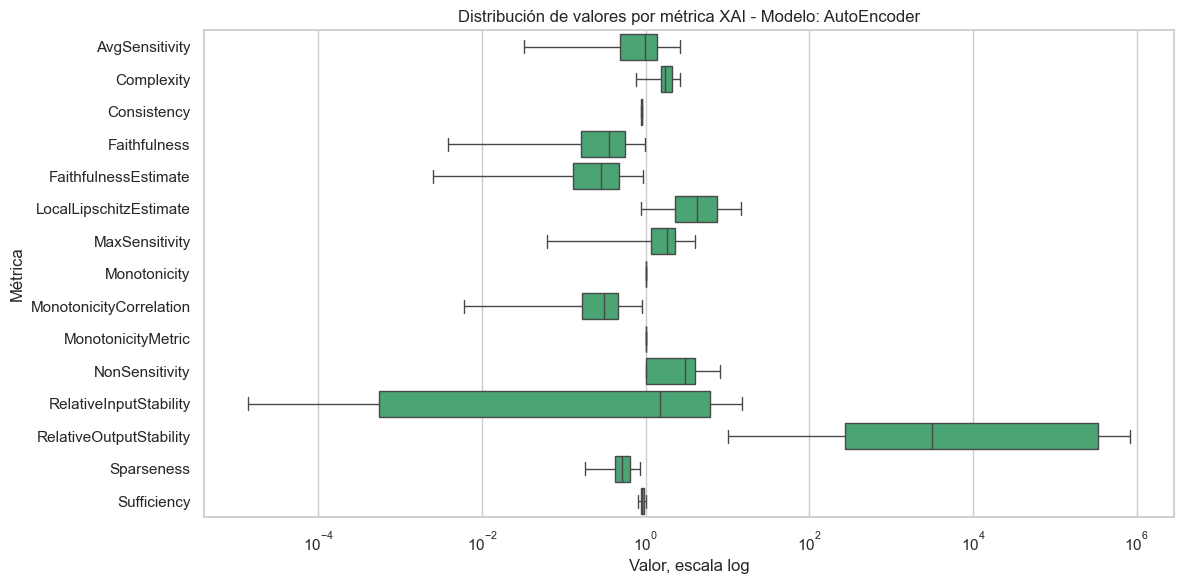

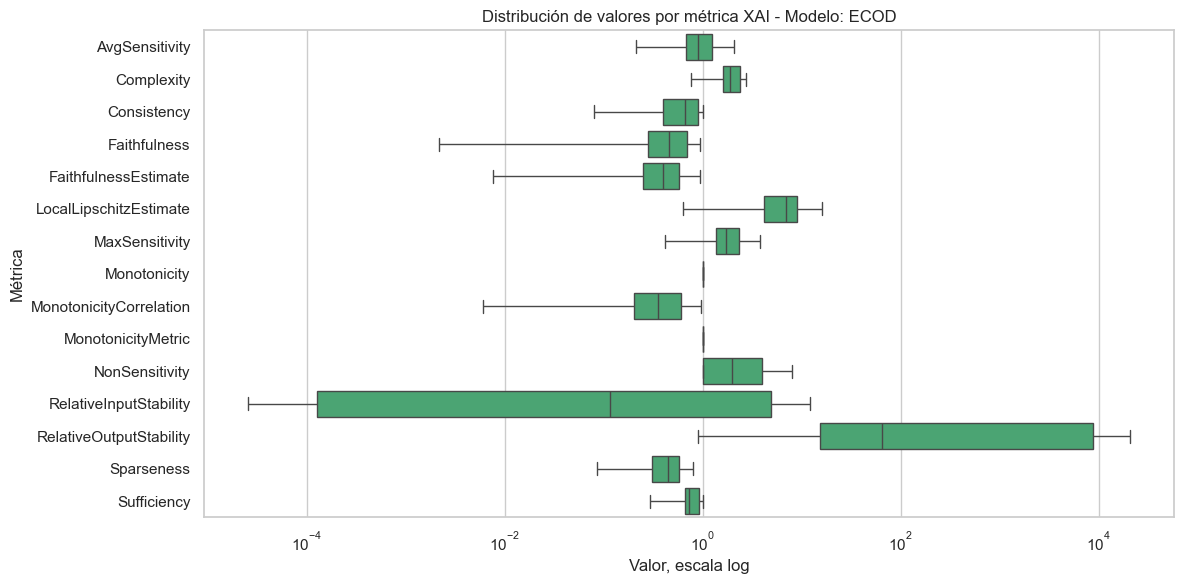

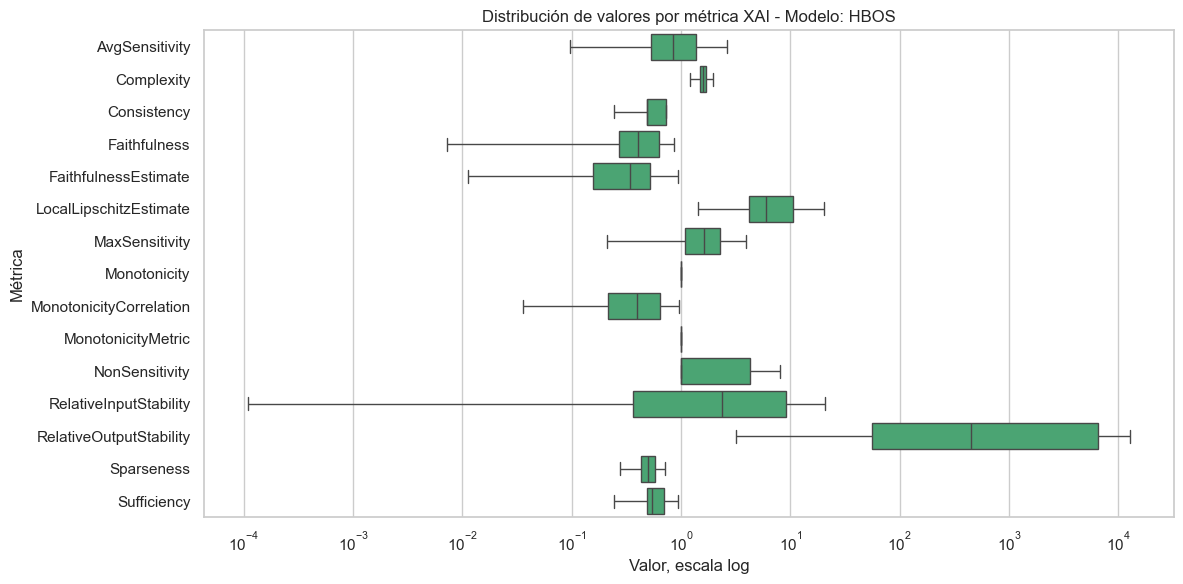

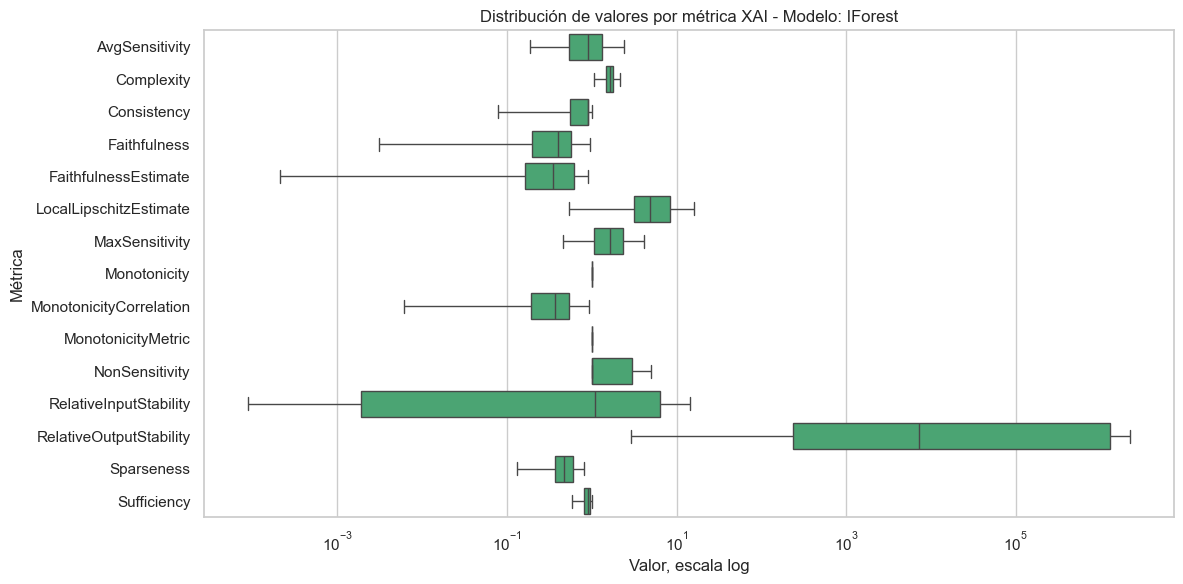

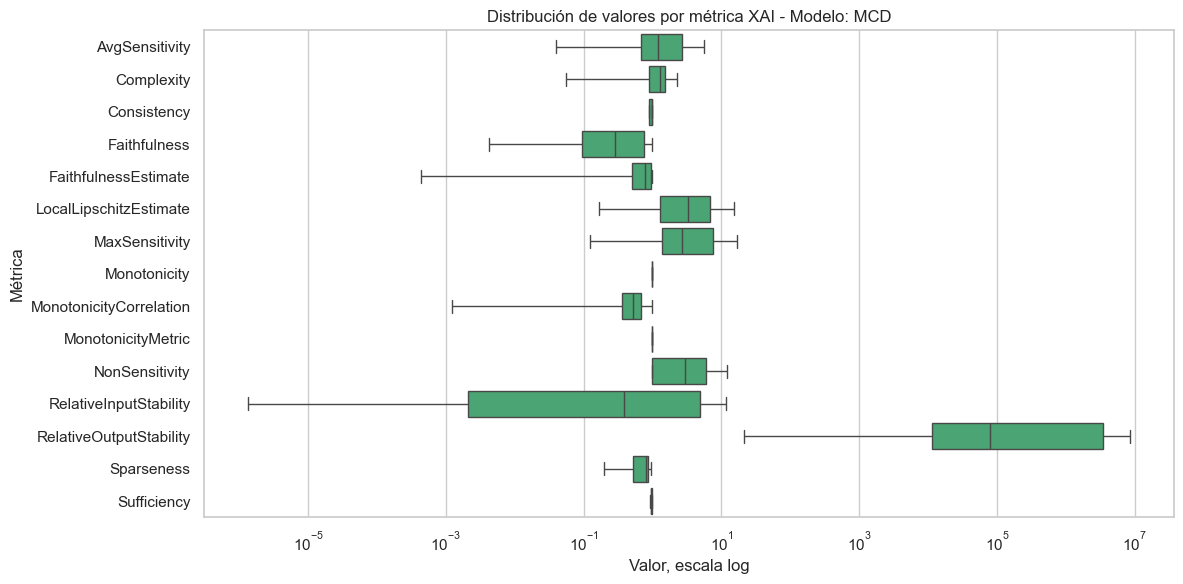

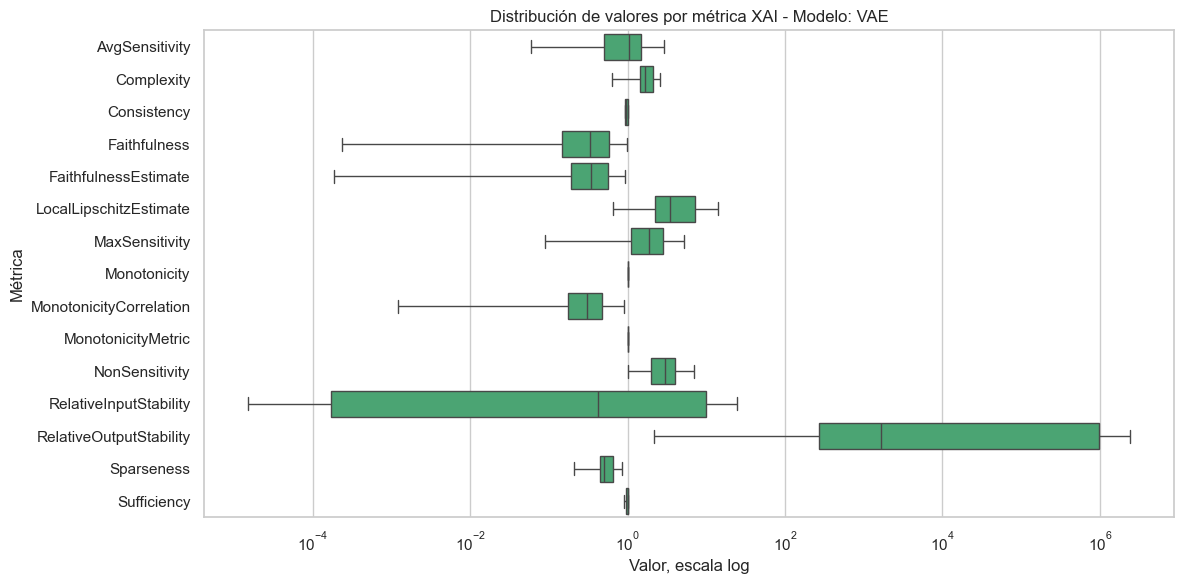

In [77]:
for model_name, model_df in plot_long_positive.groupby("model_name"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=model_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Modelo: {model_name}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()

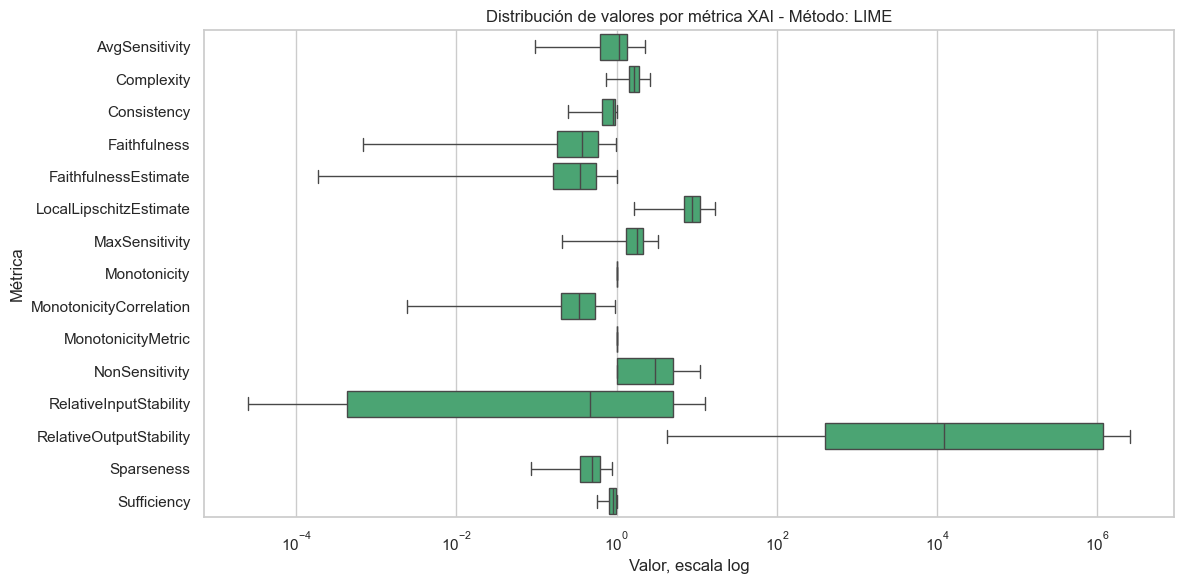

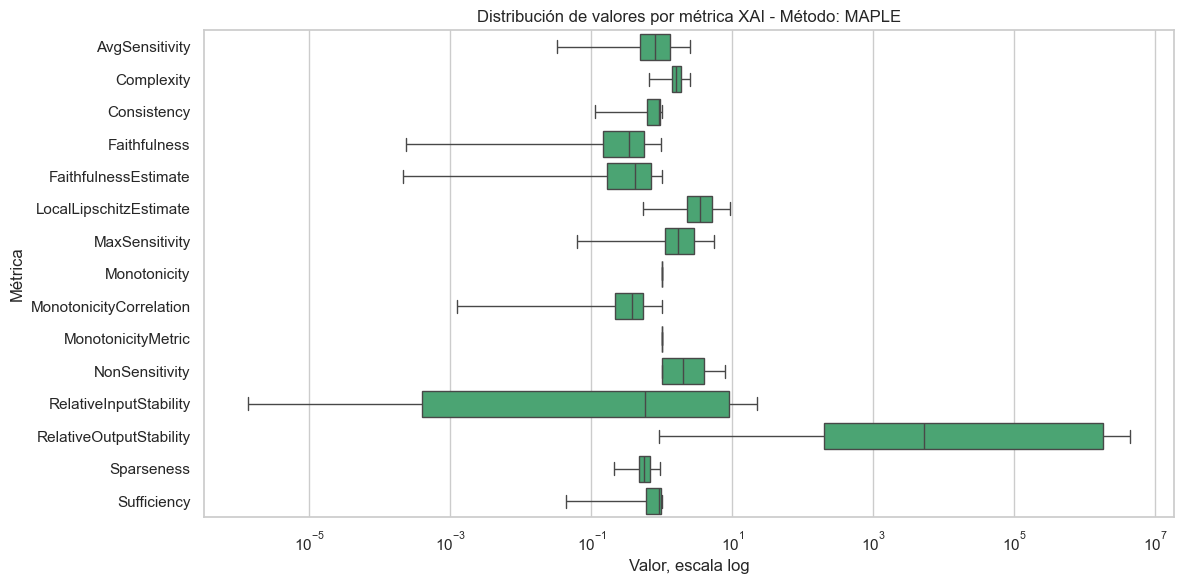

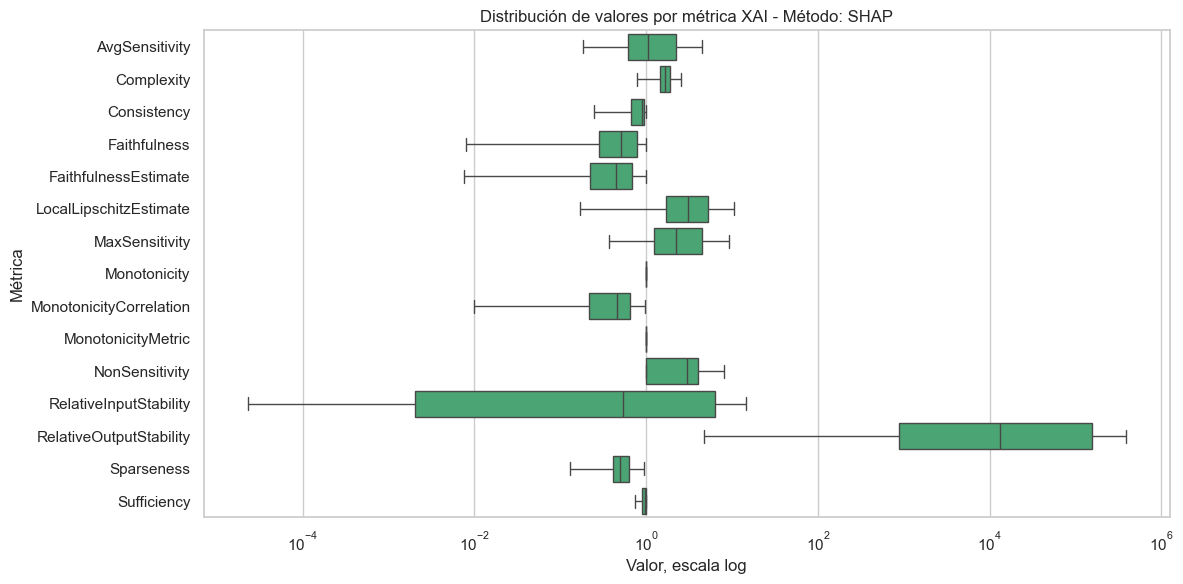

In [78]:
for xai_method, xai_df in plot_long_positive.groupby("xai_method"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=xai_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Método: {xai_method}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()

## Por dataset

In [79]:
dataset_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="dataset_name",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_dataset",
    remaining_factors=["model_name", "xai_method"],
    min_periods_corr=20,
    show_plots=False
)


===== dataset_name: AHU21 =====
Filas: 840
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['MonotonicityMetric']
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
23,Complexity,Sparseness,-0.996416,0.000000e+00,840,0.996416,True
5,AvgSensitivity,MaxSensitivity,0.861619,9.368792e-208,700,0.861619,True
85,RelativeInputStability,RelativeOutputStability,0.826123,2.073335e-120,477,0.826123,True
88,RelativeOutputStability,Sparseness,0.630144,2.255712e-54,479,0.630144,True
22,Complexity,RelativeOutputStability,-0.618429,6.987907e-52,479,0.618429,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
4,Consistency,model_name,662.924309,2.296894e-143,True
24,Sparseness,model_name,474.353229,1.723490e-102,True
2,Complexity,model_name,461.472110,1.065505e-99,True
11,LocalLipschitzEstimate,xai_method,451.746814,8.024643e-99,True
14,Monotonicity,model_name,328.598923,6.415629e-71,True
22,RelativeOutputStability,model_name,327.078518,1.368958e-70,True
27,Sufficiency,xai_method,280.051602,1.540165e-61,True
26,Sufficiency,model_name,187.760340,1.859503e-40,True
20,RelativeInputStability,model_name,177.339351,3.311467e-38,True
7,Faithfulness,xai_method,154.565926,2.731716e-34,True



===== dataset_name: ARAMIS20 =====
Filas: 1260
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


...

,metric,factor,H,p_value,significant_0.05
14,Monotonicity,model_name,1259.000000,4.869849e-270,True
4,Consistency,model_name,682.755238,2.628495e-145,True
20,NonSensitivity,model_name,629.571349,8.237067e-134,True
11,LocalLipschitzEstimate,xai_method,429.003059,6.968982e-94,True
28,Sufficiency,model_name,385.060332,4.917026e-81,True
3,Complexity,xai_method,347.151349,4.140401e-76,True
27,Sparseness,xai_method,323.960296,4.496924e-71,True
24,RelativeOutputStability,model_name,161.855051,3.982492e-33,True
1,AvgSensitivity,xai_method,131.534649,2.739137e-29,True
10,LocalLipschitzEstimate,model_name,133.222675,4.925976e-27,True



===== dataset_name: MetroPT3 =====
Filas: 756
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,p_value,n,abs_corr,significant_0.05
25,Complexity,Sparseness,-0.994499,0.000000e+00,756,0.994499,True
5,AvgSensitivity,MaxSensitivity,0.896936,1.890882e-269,756,0.896936,True


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
14,Monotonicity,model_name,755.000000,6.270423e-161,True
4,Consistency,model_name,595.308343,2.087153e-126,True
29,Sufficiency,xai_method,547.034814,1.632674e-119,True
16,MonotonicityCorrelation,model_name,408.073864,5.395133e-86,True
26,Sparseness,model_name,331.417533,1.749462e-69,True
2,Complexity,model_name,320.032505,4.926053e-67,True
11,LocalLipschitzEstimate,xai_method,269.796104,2.597290e-59,True
21,NonSensitivity,xai_method,265.541442,2.179759e-58,True
20,NonSensitivity,model_name,269.019634,4.544201e-56,True
18,MonotonicityMetric,model_name,113.026333,9.390901e-23,True


In [80]:
variability_by_dataset = collect_variability(dataset_results, "dataset_name")
display(variability_by_dataset)

,dataset_name,metric,mean,std,range,missing_pct,n_unique
0,AHU21,RelativeOutputStability,3.296318e+08,2.668678e+09,5.217775e+10,42.976190,479
1,AHU21,MaxSensitivity,1.666445e+01,1.301885e+02,1.907456e+03,0.000000,840
2,AHU21,AvgSensitivity,6.869378e+00,5.062654e+01,7.693539e+02,16.666667,700
3,AHU21,LocalLipschitzEstimate,4.672133e+00,3.305908e+00,1.482565e+01,0.000000,840
4,AHU21,NonSensitivity,5.161905e+00,2.599620e+00,1.200000e+01,0.000000,13
5,AHU21,RelativeInputStability,4.018433e-01,1.455441e+00,1.209483e+01,43.095238,478
6,AHU21,Complexity,1.920454e+00,6.224137e-01,2.641201e+00,0.000000,835
7,AHU21,Faithfulness,-1.853740e-01,5.255184e-01,1.987227e+00,0.000000,840
8,AHU21,FaithfulnessEstimate,1.255035e-02,5.234629e-01,1.995796e+00,0.000000,840
9,AHU21,Sufficiency,6.098378e-01,4.340152e-01,1.000000e+00,0.000000,166


In [81]:
variability_by_dataset_summary = (
    variability_by_dataset
    .groupby("metric")
    .agg(
        mean_std=("std", "mean"),
        max_std=("std", "max"),
        mean_range=("range", "mean"),
        n_groups=("dataset_name", "nunique")
    )
    .sort_values("mean_std", ascending=False)
)

display(variability_by_dataset_summary)

,mean_std,max_std,mean_range,n_groups
metric,,,,
RelativeOutputStability,1.272289e+10,3.545119e+10,2.656531e+11,3
MaxSensitivity,2.855742e+03,8.432331e+03,4.242887e+04,3
RelativeInputStability,2.848102e+03,4.790200e+03,4.766059e+04,3
AvgSensitivity,2.023171e+03,6.016957e+03,3.059590e+04,3
LocalLipschitzEstimate,3.847077e+00,4.441848e+00,2.328275e+01,3
NonSensitivity,1.728435e+00,2.599620e+00,9.000000e+00,3
FaithfulnessEstimate,5.317232e-01,5.640328e-01,1.980007e+00,3
Faithfulness,5.076515e-01,5.462246e-01,1.981810e+00,3
Complexity,4.768842e-01,6.224137e-01,2.001358e+00,3


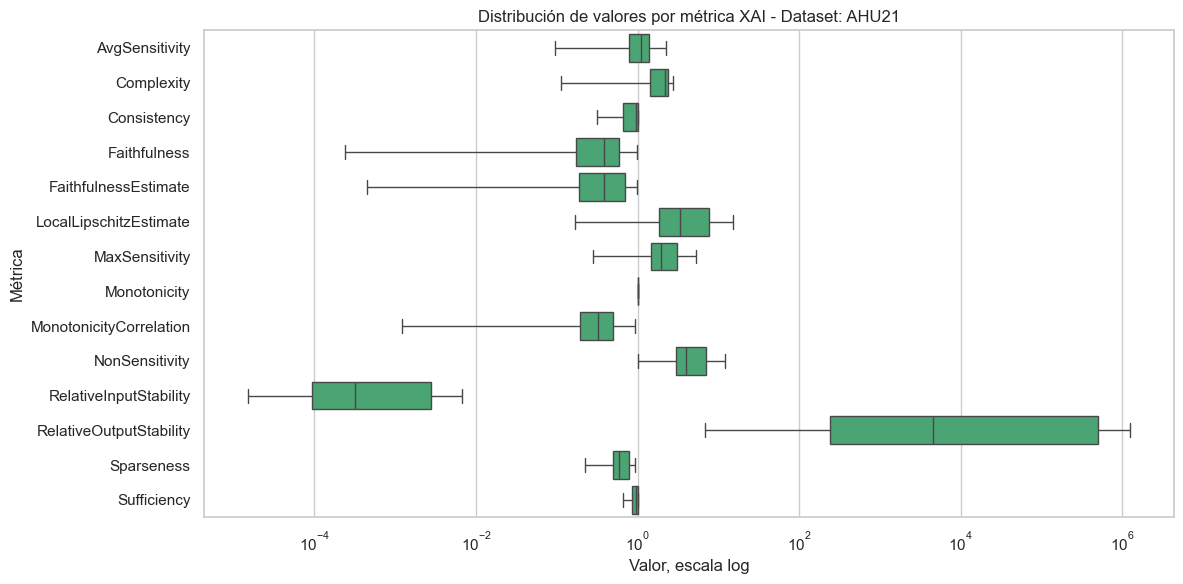

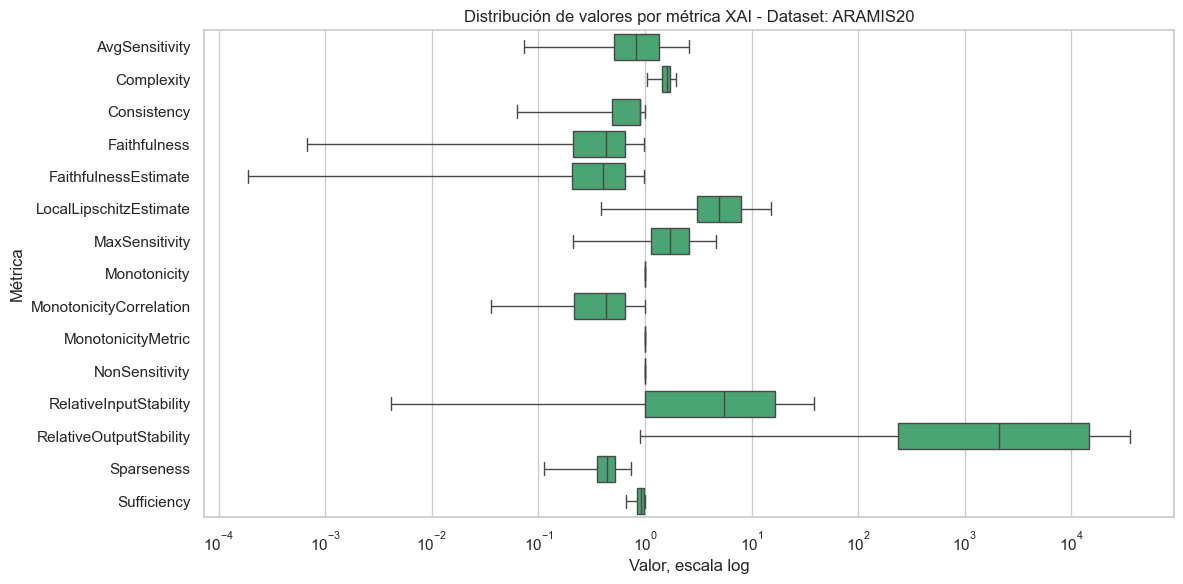

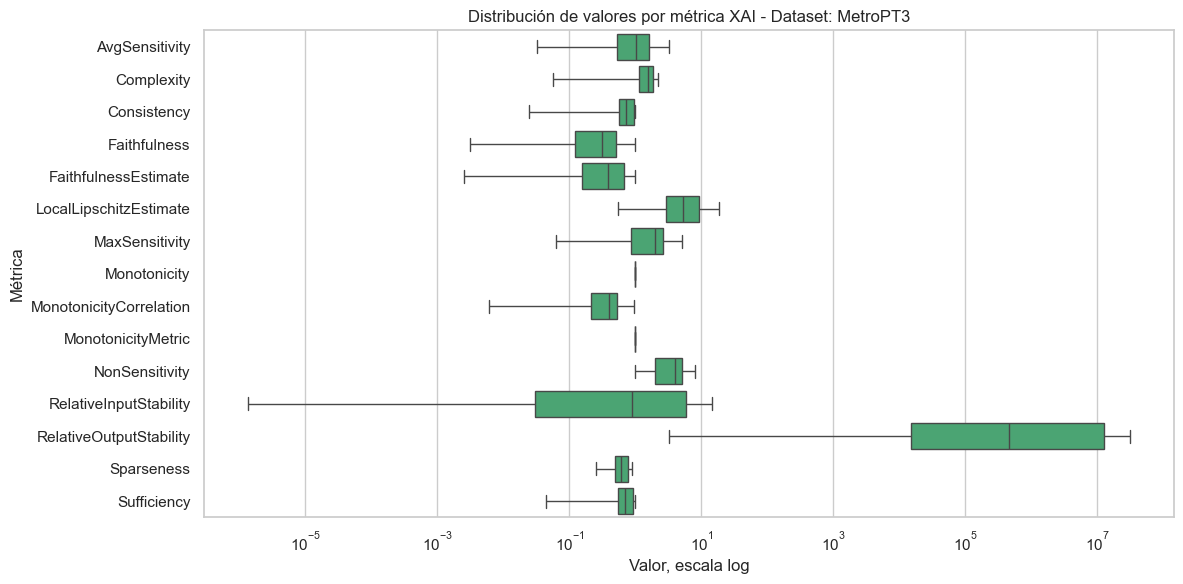

In [ ]:
for dataset_name, dataset_df in plot_long_positive.groupby("dataset_name"):
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=dataset_df,
        x="value",
        y="metric",
        color="mediumseagreen",
        showfliers=False
    )

    plt.xscale("log")
    plt.title(f"Distribución de valores por métrica XAI - Dataset: {dataset_name}")
    plt.xlabel("Valor, escala log")
    plt.ylabel("Métrica")
    plt.tight_layout()
    plt.show()